# Model Analysis v2 
 `BT_Vel_stage1` as the main target for both laboratory and field data

Model ranking uses **5-fold CV R²** as the primary criterion and **CV MSE** as the supporting error metric; split results are retained for split-vs-CV comparison only. Both datasets use `BT_Vel_stage1` (lab N = 11,119; field N = 5,230) consistently across all analyses.


## 1. Feature Correlation 

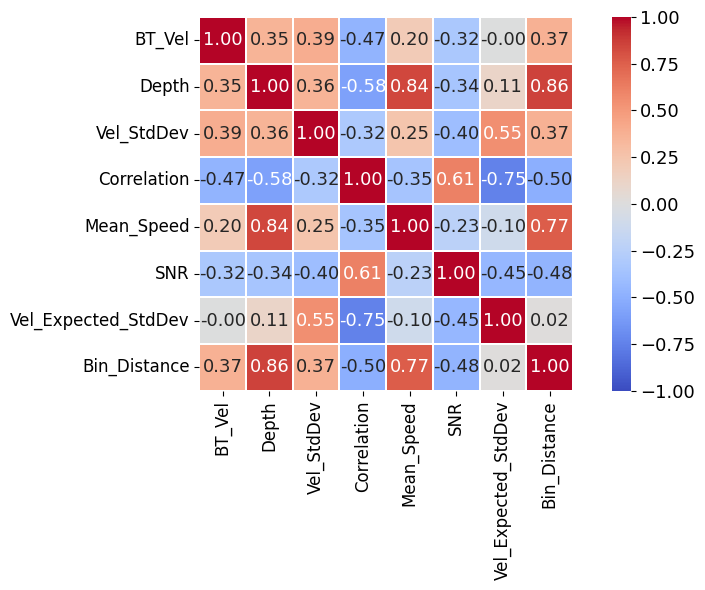

In [1]:
##lab

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the processed Excel file
input_path = (
    r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive'
    r'\Personal _Github\ADCP_ML_DL_Journal_1\Processed_LAB_Data_with_BS.xlsx'
)

final_df = pd.read_excel(input_path)

# Selected features
features_to_check = [
    'BT_Vel_stage1',
    'Depth',
    'Vel_StdDev',
    'Correlation',
    'Mean_Speed',
    'SNR',
    'Vel_Expected_StdDev',
    'Bin_Distance'
]

# Keep only existing features
available_features = [f for f in features_to_check if f in final_df.columns]

# Select data
features_only_df = final_df[available_features]

# Correlation matrix
correlation_matrix = features_only_df.corr()

# Rename only for figure display
label_map = {
    'BT_Vel_stage1': 'BT_Vel'
}

correlation_matrix_plot = correlation_matrix.rename(
    index=label_map,
    columns=label_map
)

# Create figure
plt.figure(figsize=(9, 6))

ax = sns.heatmap(
    correlation_matrix_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    cbar=True,
    annot_kws={
        "size": 13,      # bigger numbers inside cells
        "weight": "normal"
    },
    linewidths=0.3,
    linecolor="white"
)

# Axis label formatting
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    ha="center",
    fontsize=12
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=12
)

# Colorbar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)

# Remove title for clean manuscript-style figure
ax.set_title("")

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "Feature_Correlation_Heatmap_Lab_Data.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

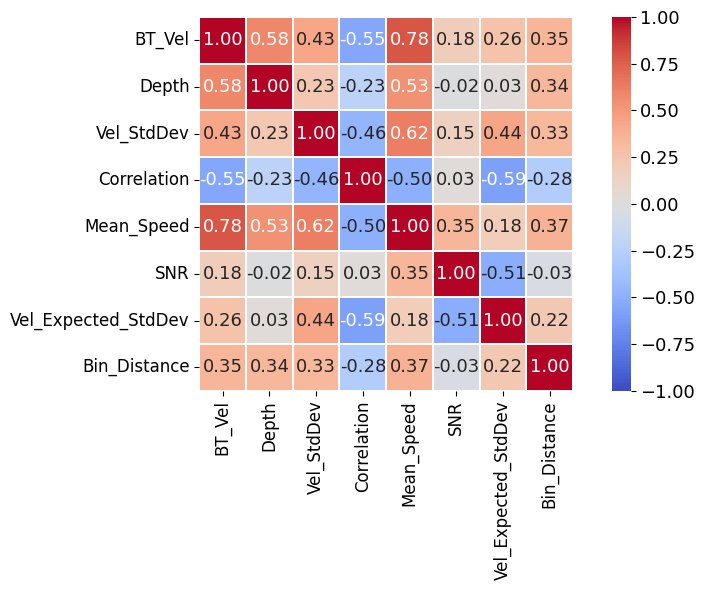

In [2]:
##field 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the processed Excel file
input_path = (
    r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive'
    r'\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx'
)

final_df = pd.read_excel(input_path)

# Selected features
features_to_check = [
    'BT_Vel_stage1',
    'Depth',
    'Vel_StdDev',
    'Correlation',
    'Mean_Speed',
    'SNR',
    'Vel_Expected_StdDev',
    'Bin_Distance'
]

# Keep only existing features
available_features = [f for f in features_to_check if f in final_df.columns]

# Select data
features_only_df = final_df[available_features]

# Correlation matrix
correlation_matrix = features_only_df.corr()

# Rename only for figure display
label_map = {
    'BT_Vel_stage1': 'BT_Vel'
}

correlation_matrix_plot = correlation_matrix.rename(
    index=label_map,
    columns=label_map
)

# Create figure
plt.figure(figsize=(9, 6))

ax = sns.heatmap(
    correlation_matrix_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    cbar=True,
    annot_kws={
        "size": 13,      # bigger numbers inside cells
        "weight": "normal"
    },
    linewidths=0.3,
    linecolor="white"
)

# Axis label formatting
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    ha="center",
    fontsize=12
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=12
)

# Colorbar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)

# Remove title for clean manuscript-style figure
ax.set_title("")

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "Feature_Correlation_Heatmap_field_Data.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## 2. Model performance 

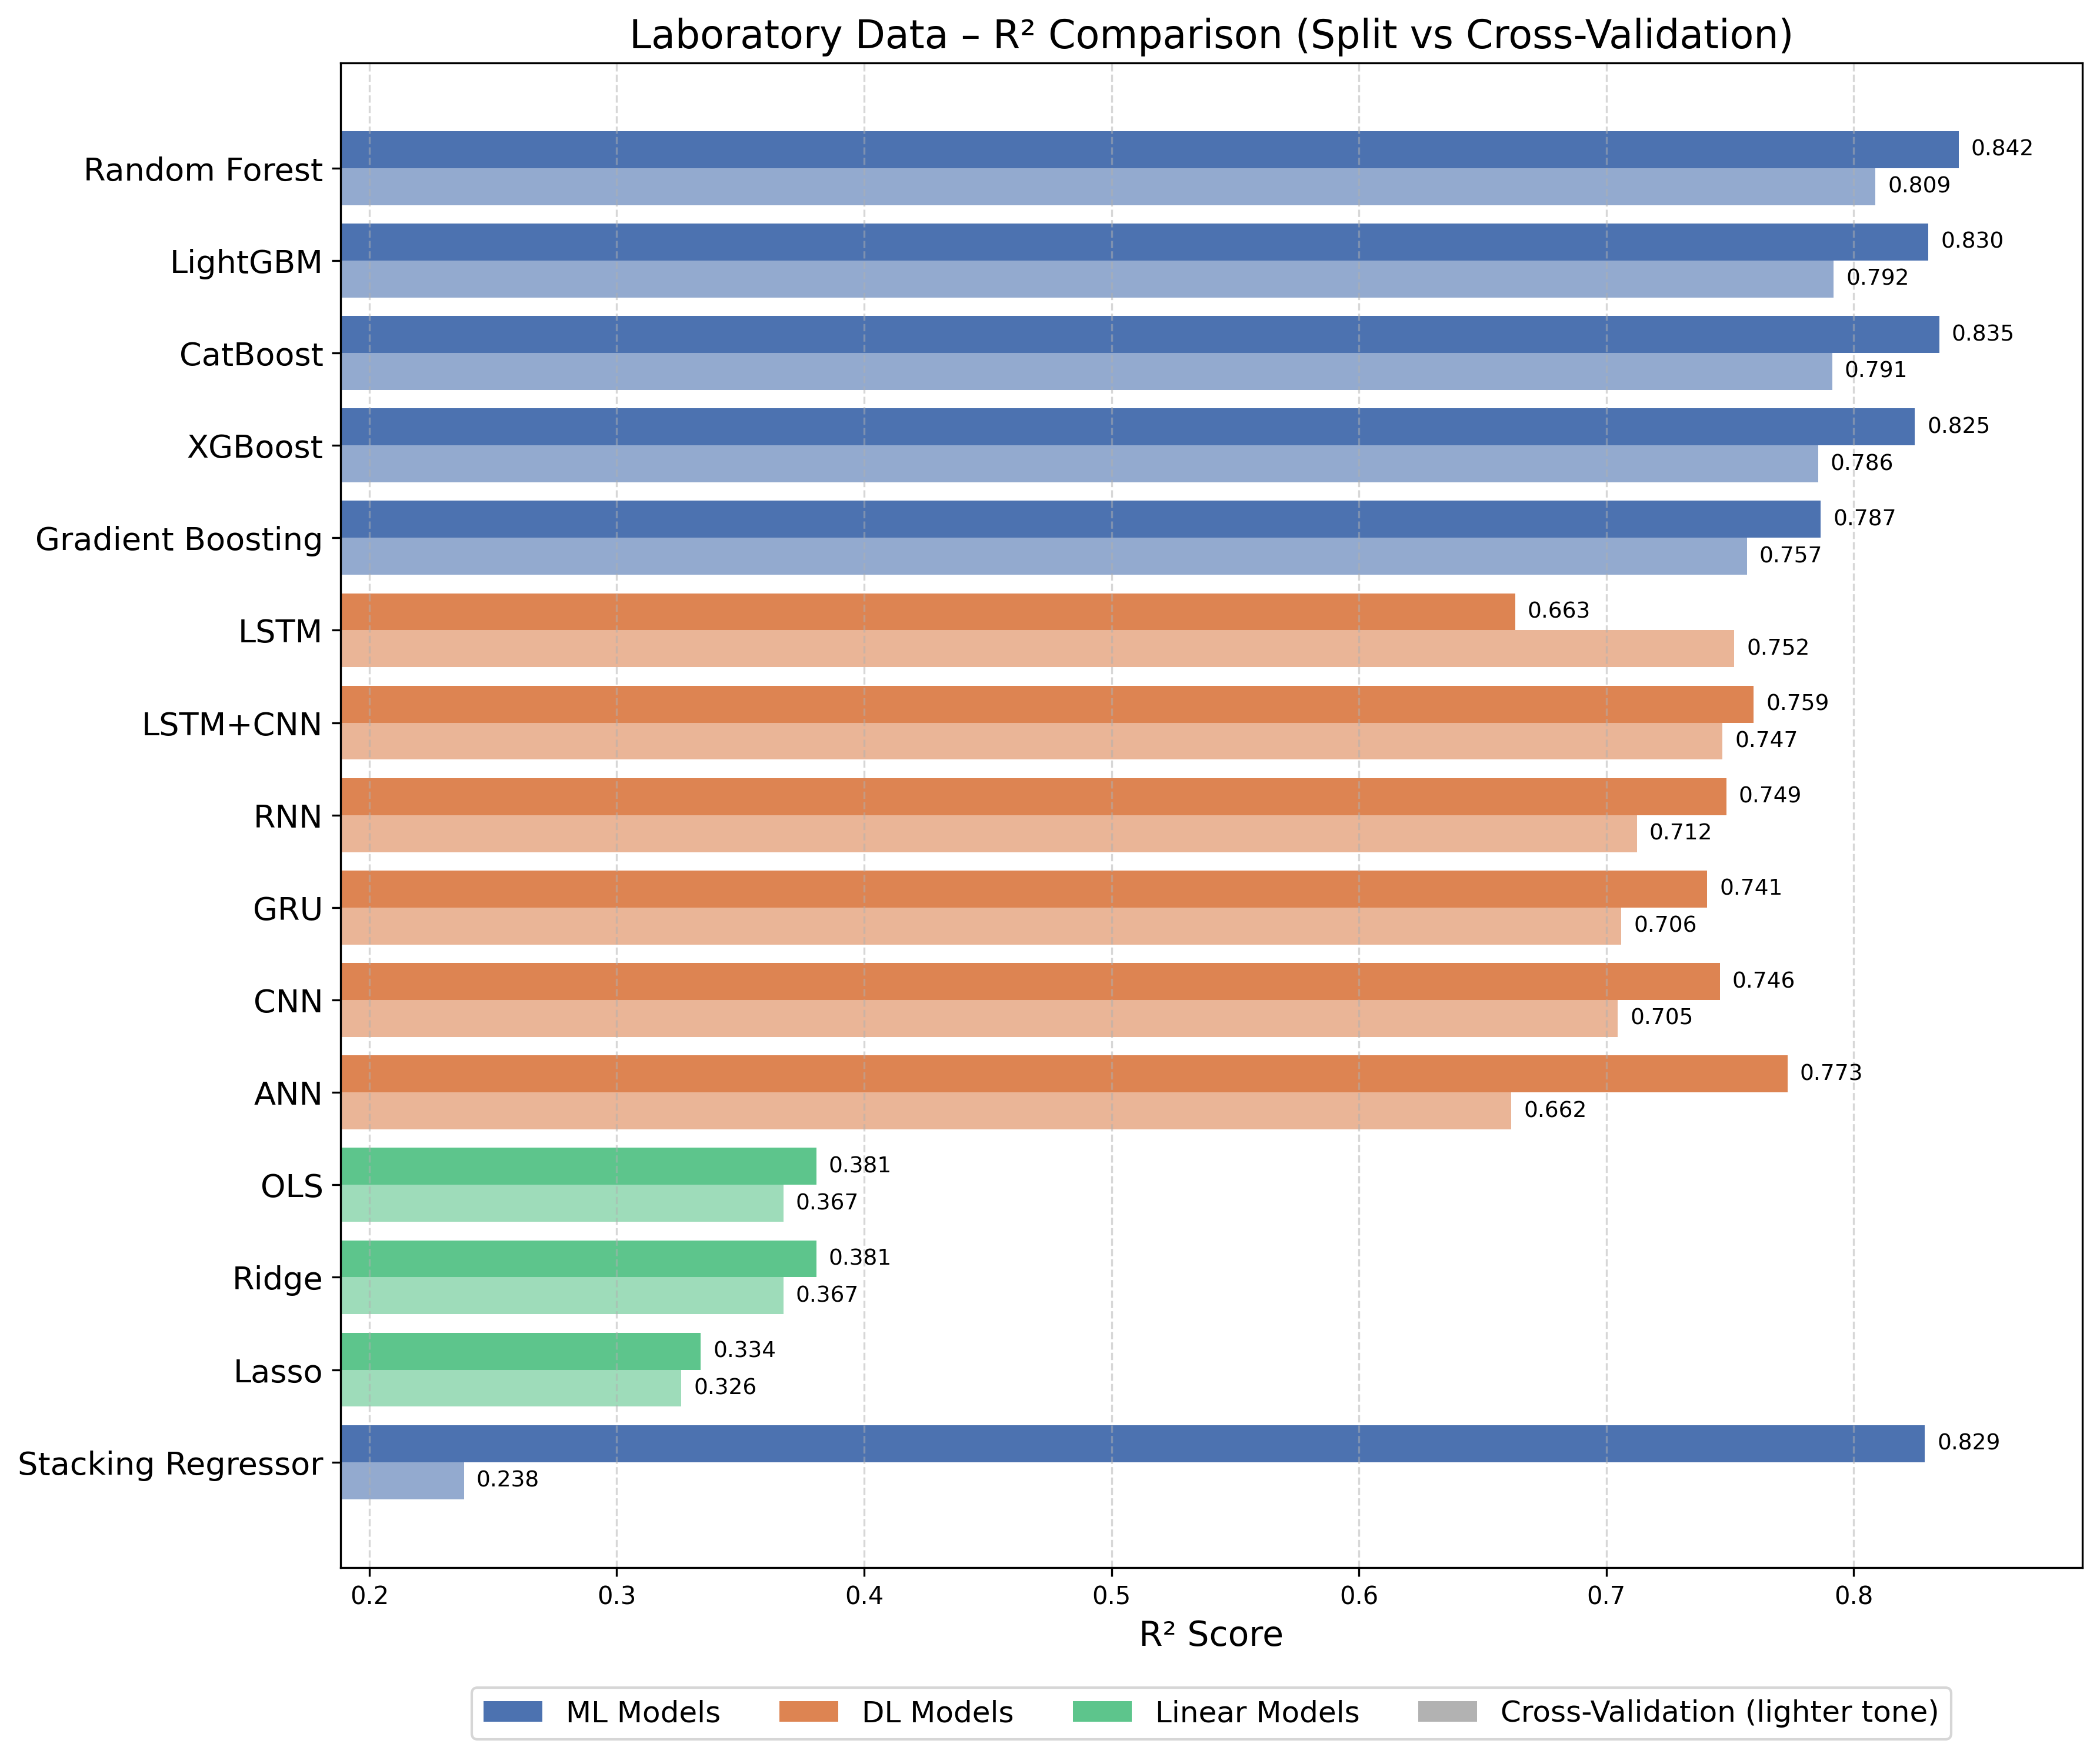

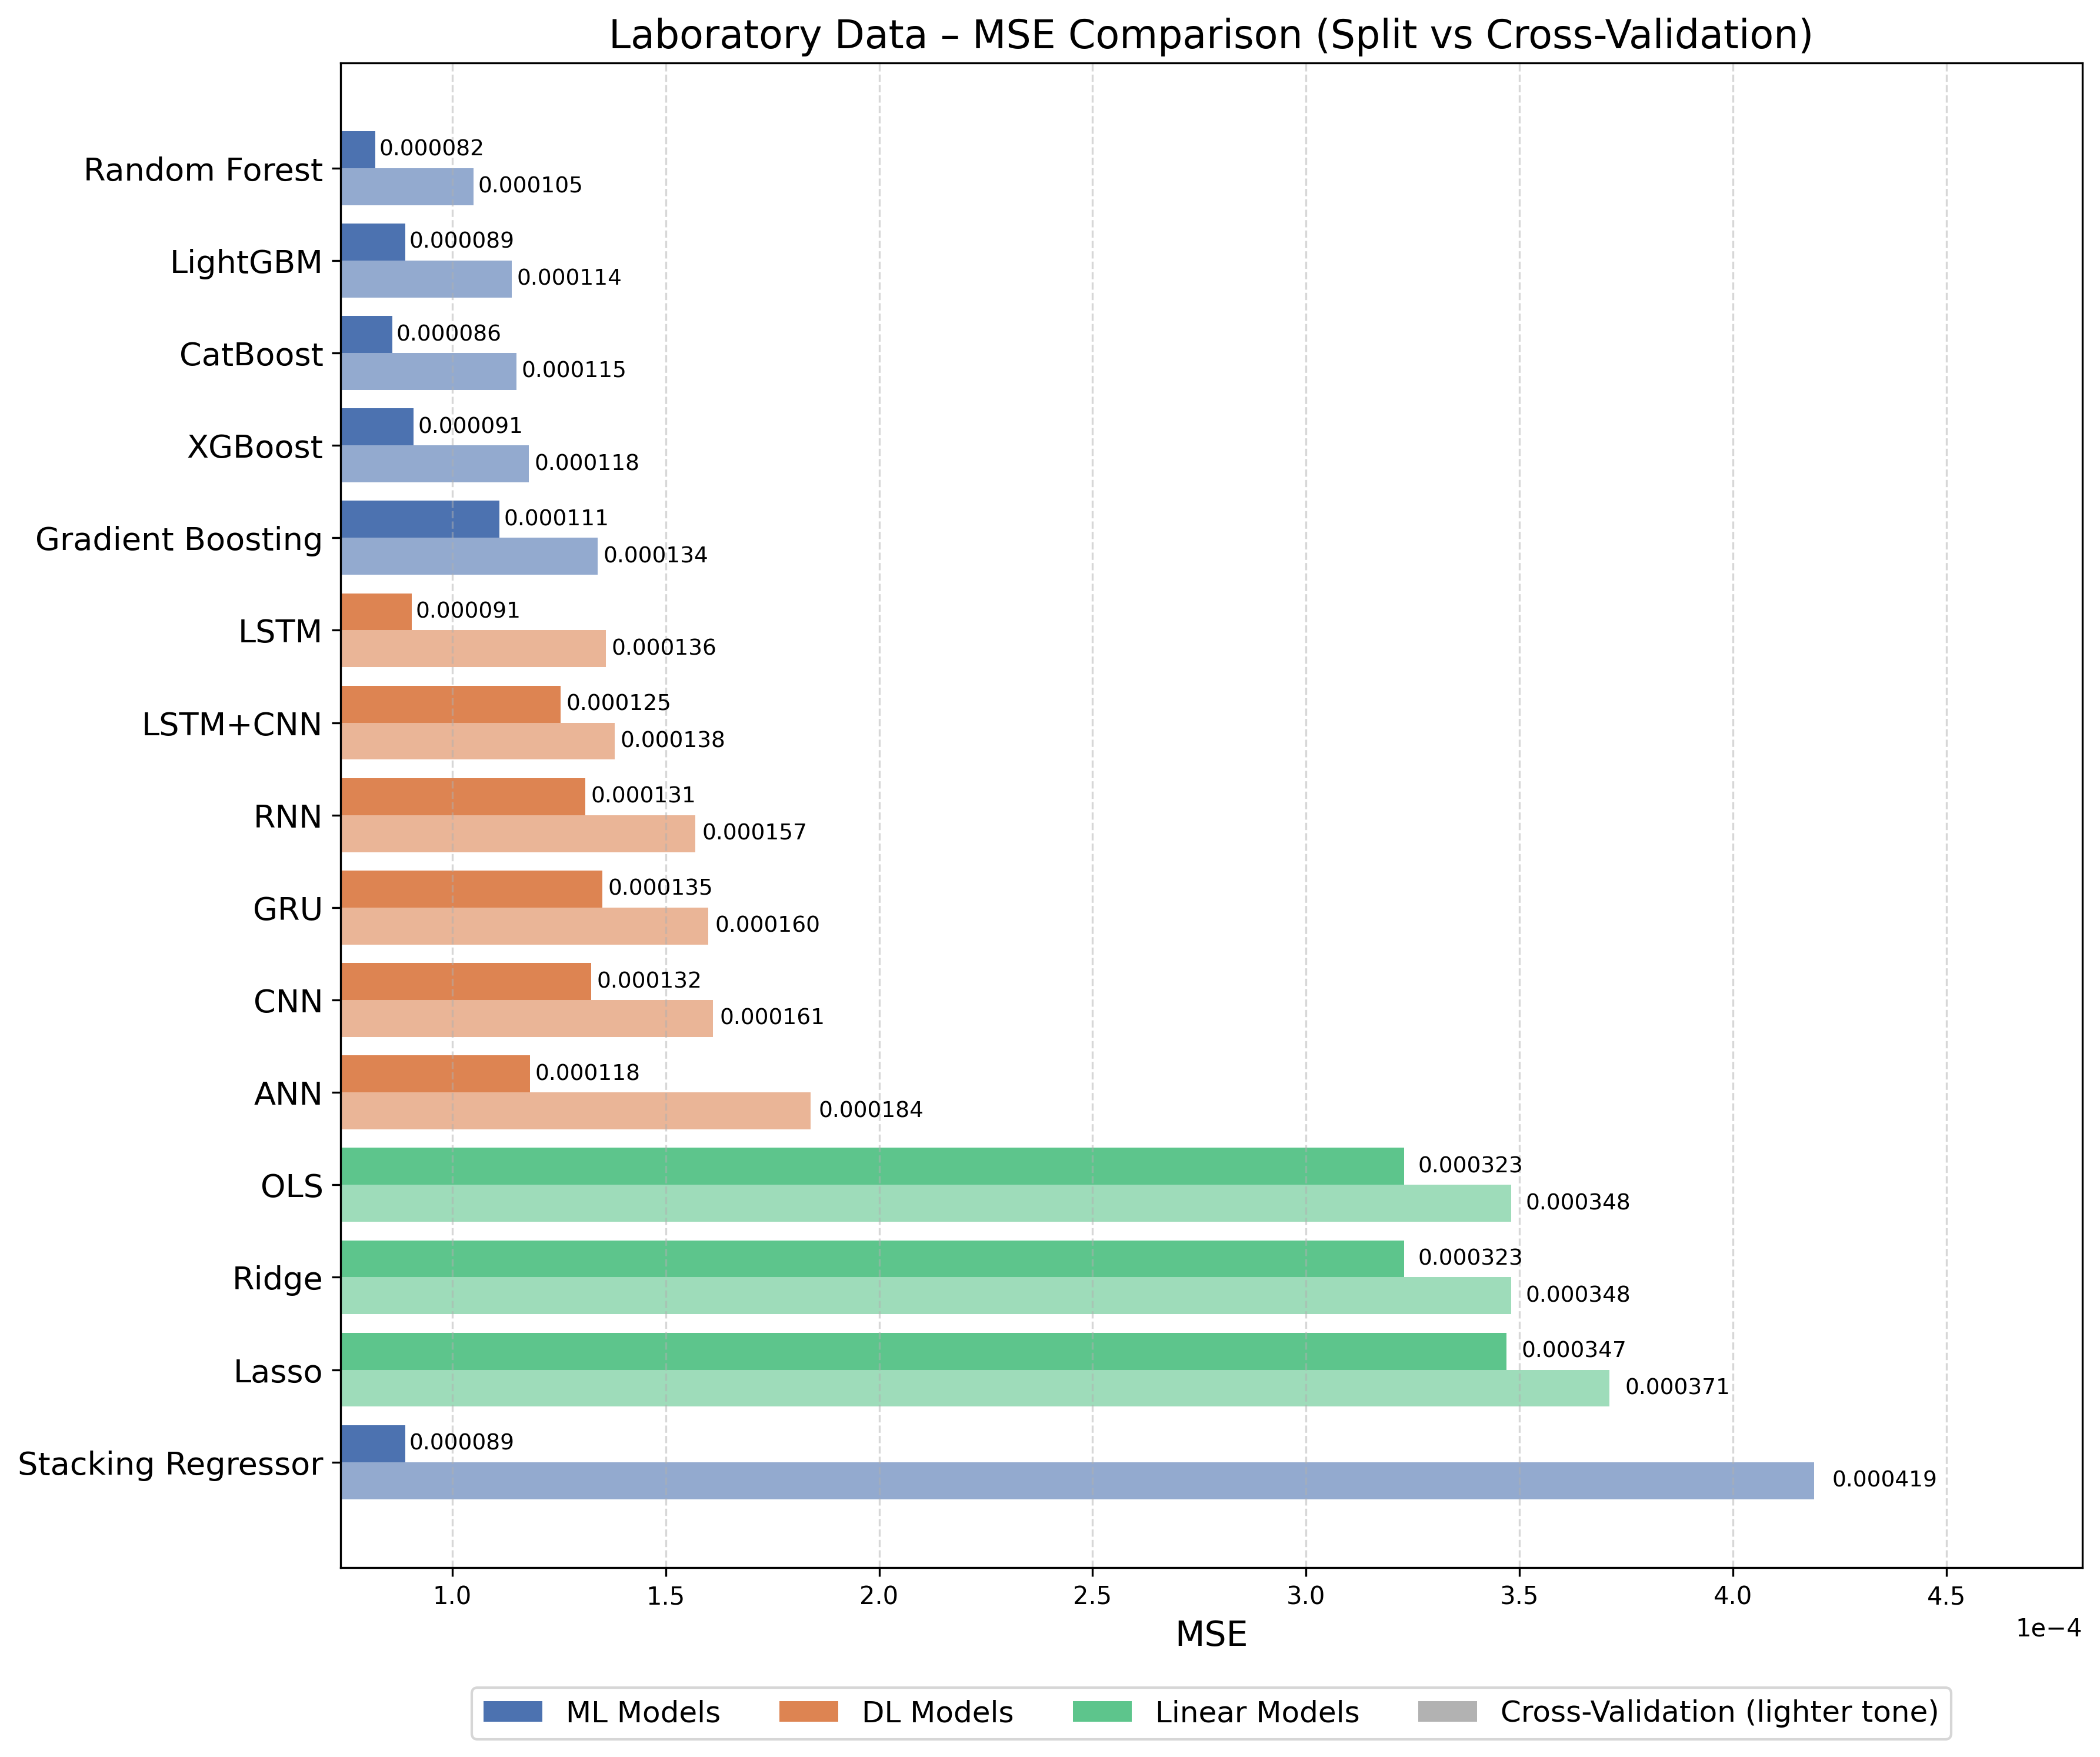

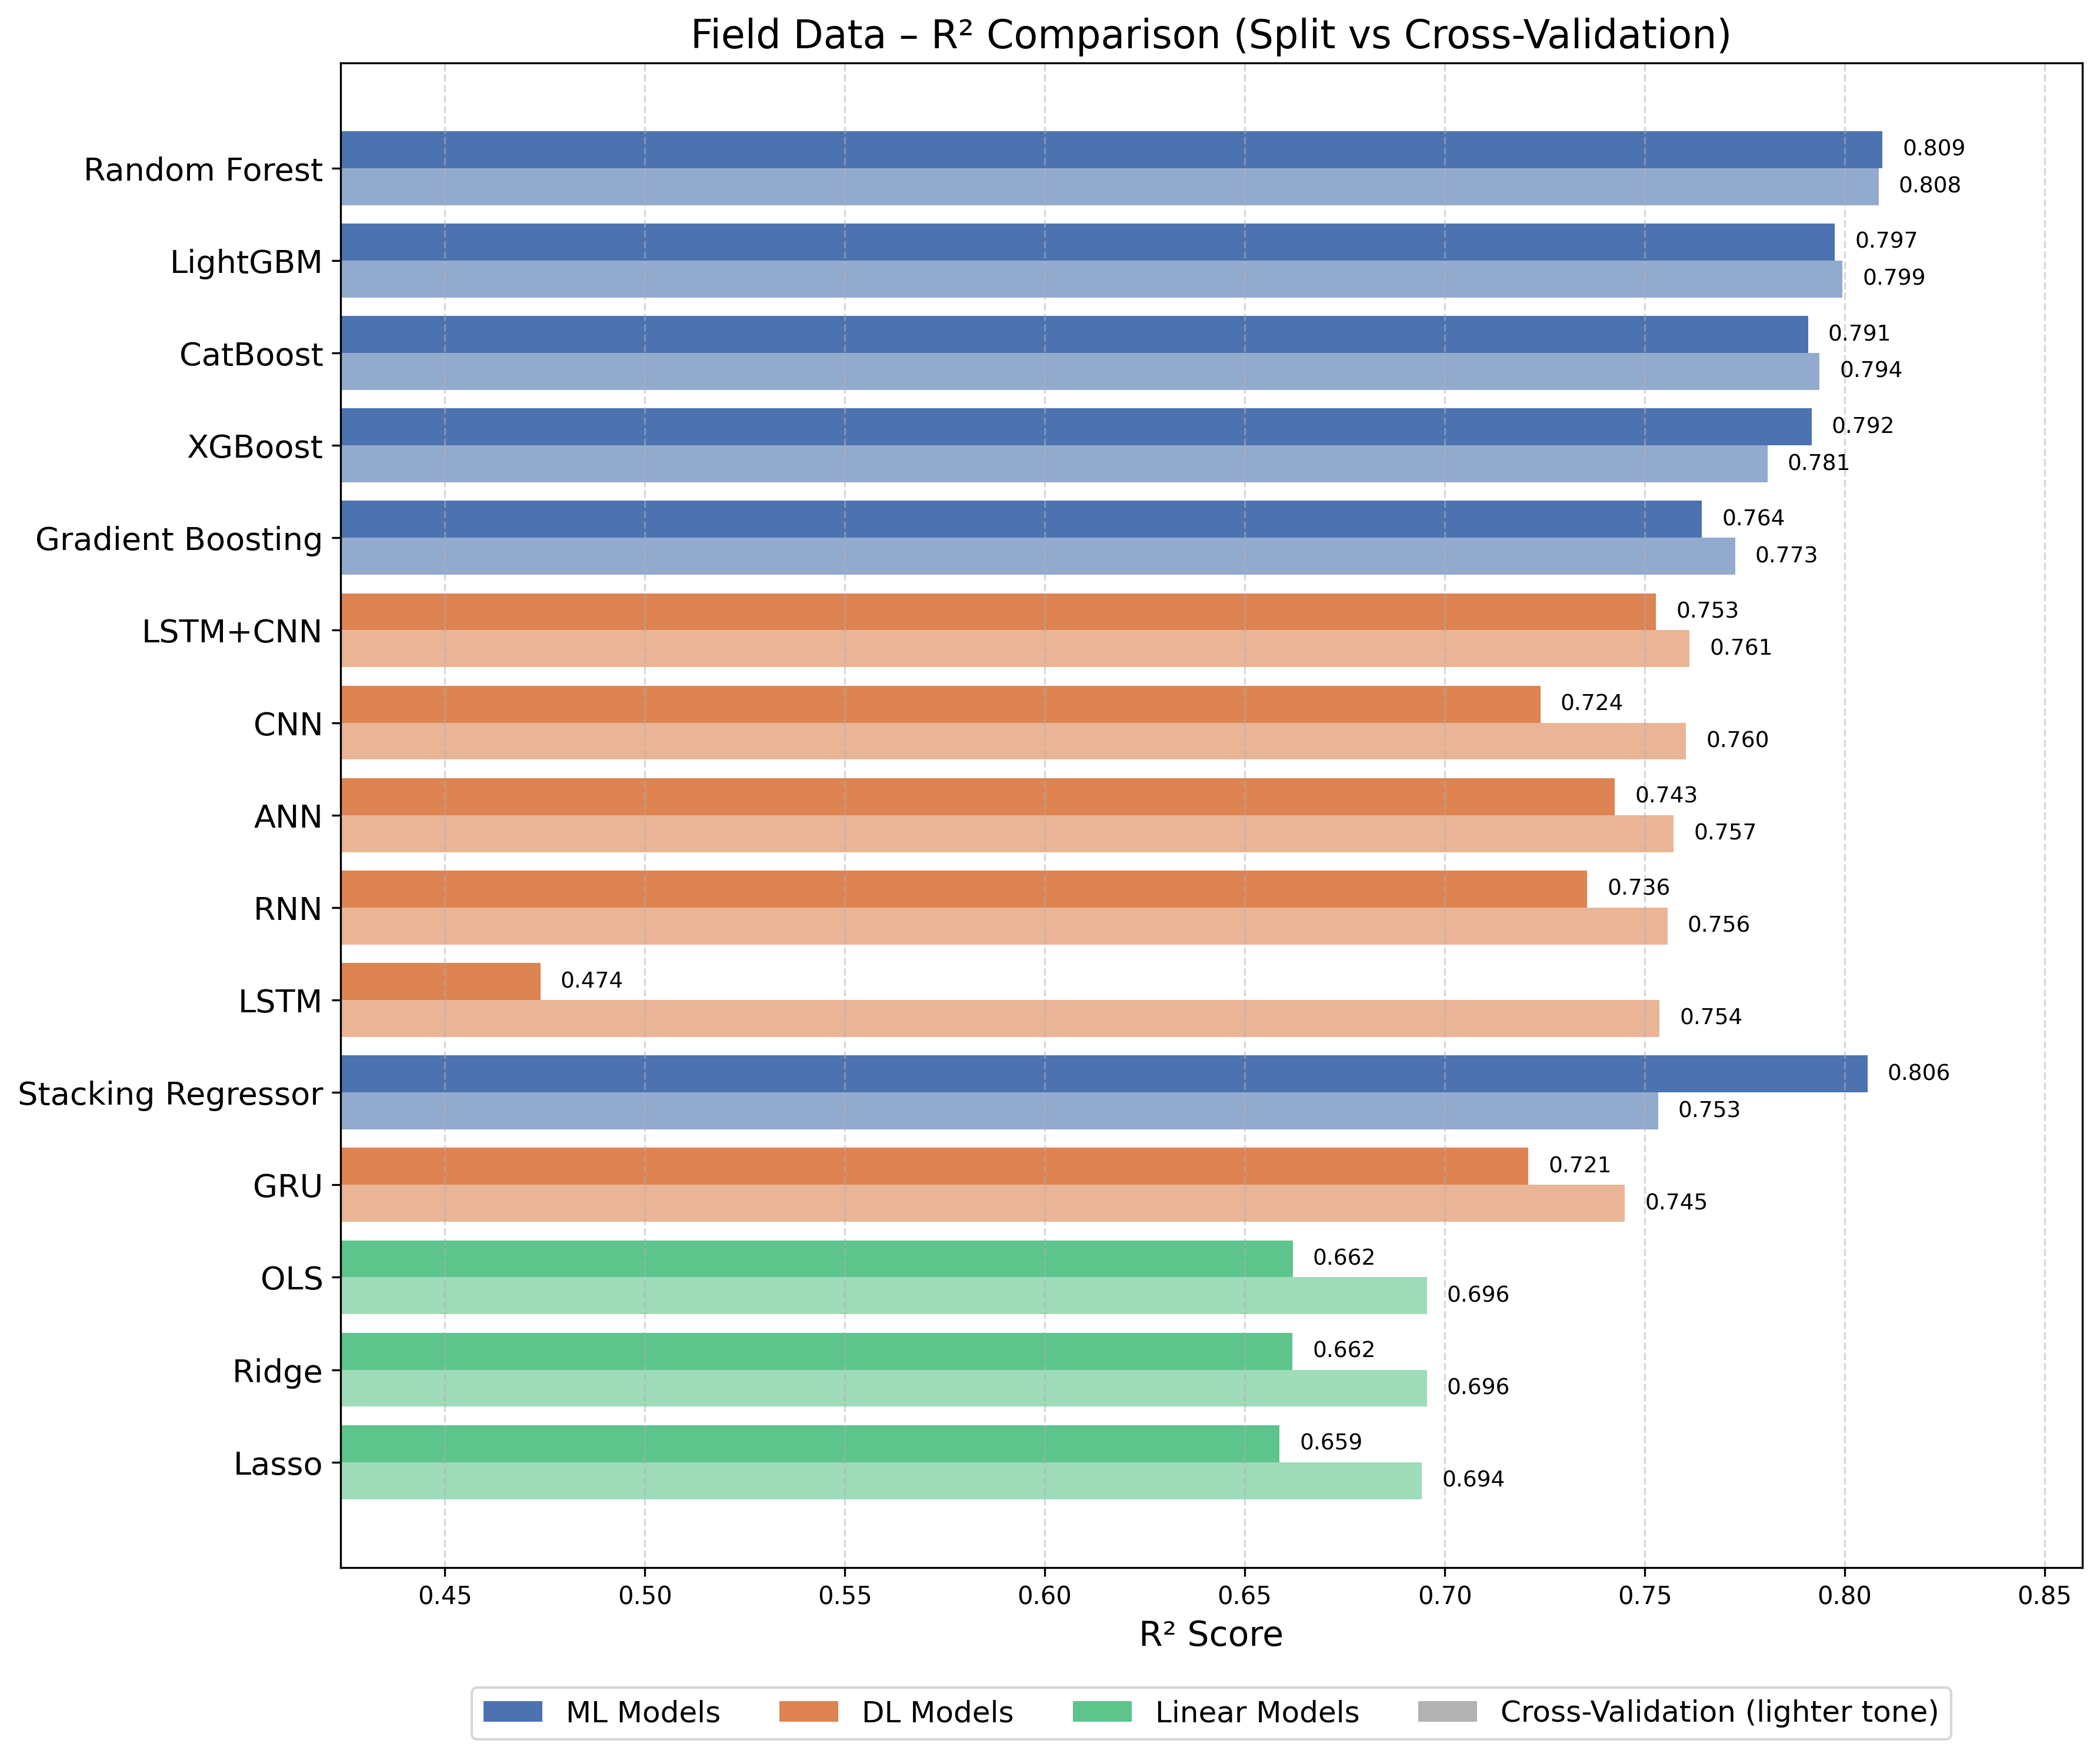

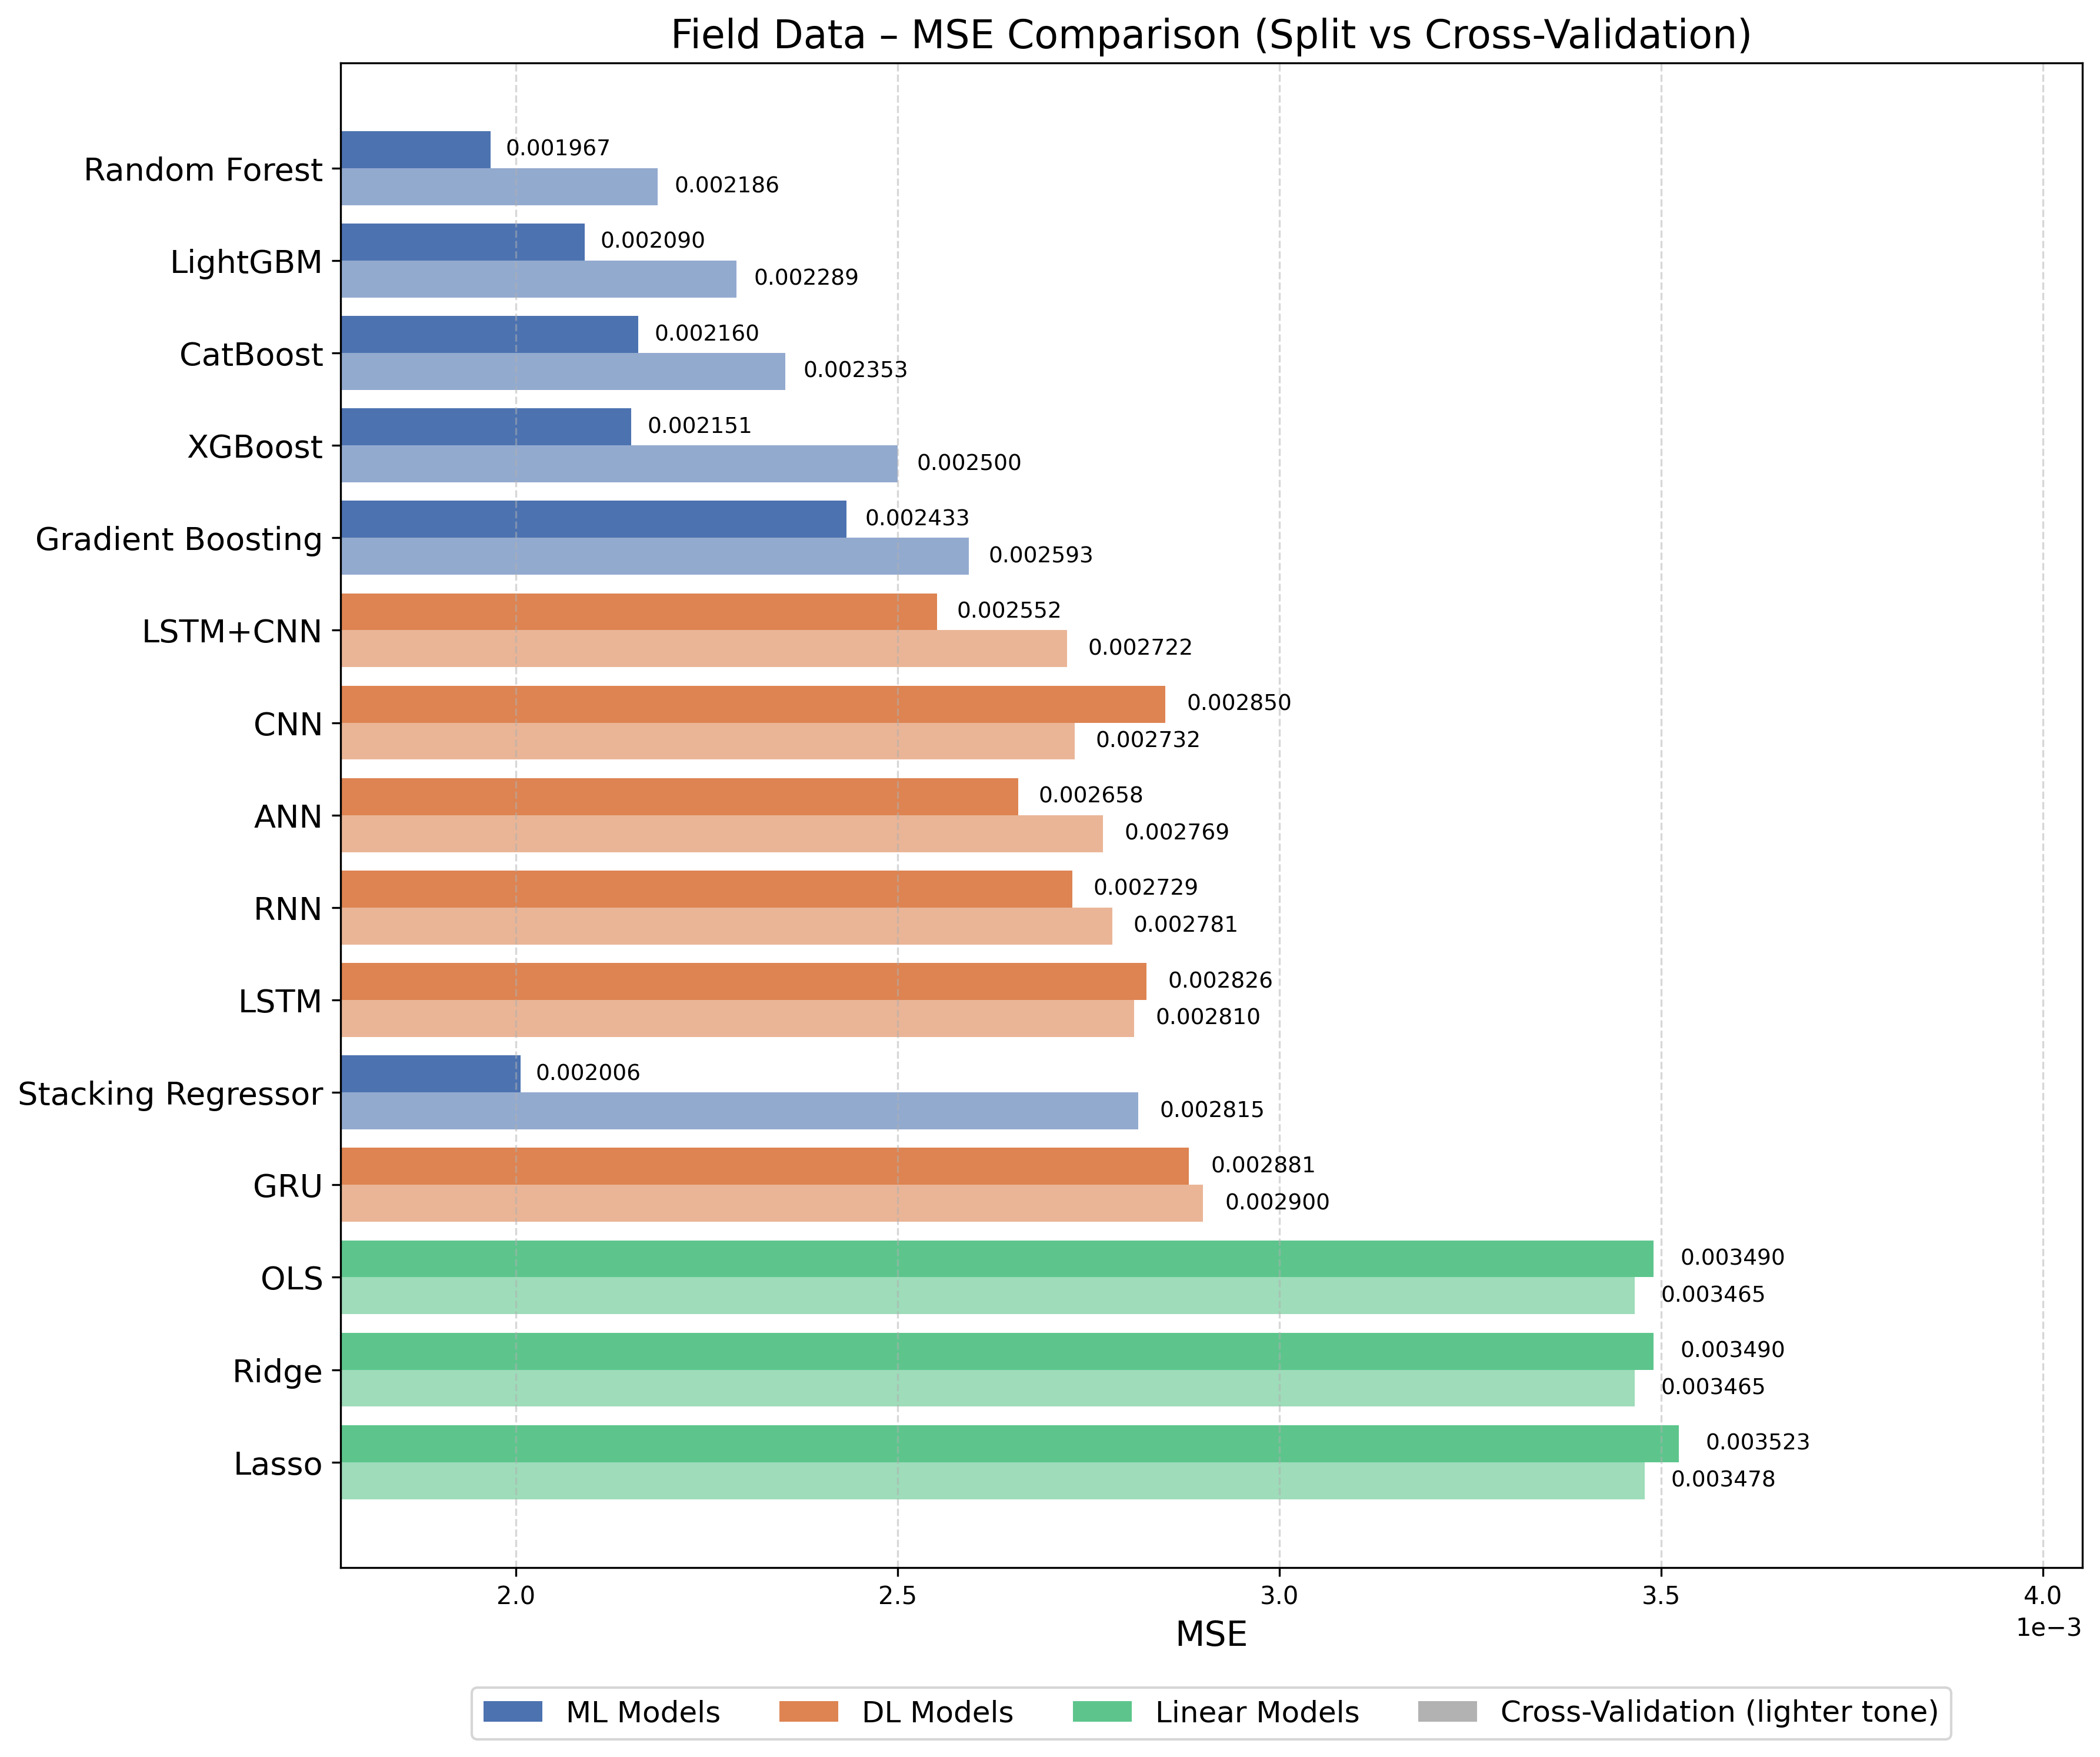


Laboratory models ranked by CV R²


,Model,Type,R2_Split,R2_CV,MSE_Split,MSE_CV
0,Random Forest,ML,0.8424,0.8088,0.000082,0.000105
1,LightGBM,ML,0.8302,0.7919,0.000089,0.000114
2,CatBoost,ML,0.8346,0.7913,0.000086,0.000115
3,XGBoost,ML,0.8247,0.7856,0.000091,0.000118
4,Gradient Boosting,ML,0.7866,0.7568,0.000111,0.000134
5,LSTM,DL,0.6631,0.7517,0.000091,0.000136
6,LSTM+CNN,DL,0.7595,0.7469,0.000125,0.000138
7,RNN,DL,0.7485,0.7124,0.000131,0.000157
8,GRU,DL,0.7407,0.7061,0.000135,0.000160
9,CNN,DL,0.7459,0.7046,0.000132,0.000161



Field models ranked by CV R²


,Model,Type,R2_Split,R2_CV,MSE_Split,MSE_CV
0,Random Forest,ML,0.8094,0.8085,0.001967,0.002186
1,LightGBM,ML,0.7975,0.7994,0.002090,0.002289
2,CatBoost,ML,0.7908,0.7937,0.002160,0.002353
3,XGBoost,ML,0.7917,0.7807,0.002151,0.002500
4,Gradient Boosting,ML,0.7643,0.7726,0.002433,0.002593
5,LSTM+CNN,DL,0.7528,0.7612,0.002552,0.002722
6,CNN,DL,0.7239,0.7603,0.002850,0.002732
7,ANN,DL,0.7425,0.7572,0.002658,0.002769
8,RNN,DL,0.7356,0.7557,0.002729,0.002781
9,LSTM,DL,0.4739,0.7537,0.002826,0.002810


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# ============================================================
# Final verified model numbers: BT_Vel_stage1
# Columns:
# Model, Type, Split R2, Split MSE, CV R2, CV R2 std, CV MSE, CV MSE std
# ============================================================

lab_raw = pd.DataFrame([
    ("Random Forest",      "ML",  0.8424, 0.000082,     0.8088, 0.0306, 0.000105, 0.000017),
    ("LightGBM",           "ML",  0.8302, 0.000089,     0.7919, 0.0274, 0.000114, 0.000014),
    ("CatBoost",           "ML",  0.8346, 0.000086,     0.7913, 0.0196, 0.000115, 0.000012),
    ("XGBoost",            "ML",  0.8247, 0.000091,     0.7856, 0.0131, 0.000118, 0.000009),
    ("Gradient Boosting",  "ML",  0.7866, 0.000111,     0.7568, 0.0255, 0.000134, 0.000018),
    ("Stacking Regressor", "ML",  0.8287, 0.000089,     0.2383, 0.0743, 0.000419, 0.000057),

    ("OLS",                "Lin", 0.3807, 0.000323,     0.3674, 0.0139, 0.000348, 0.000026),
    ("Ridge",              "Lin", 0.3807, 0.000323,     0.3674, 0.0139, 0.000348, 0.000026),
    ("Lasso",              "Lin", 0.3340, 0.000347,     0.3261, 0.0134, 0.000371, 0.000030),

    ("ANN",                "DL",  0.7732, 0.0001182598, 0.6616, 0.0706, 0.000184, 0.000031),
    ("CNN",                "DL",  0.7459, 0.0001324922, 0.7046, 0.0615, 0.000161, 0.000027),
    ("LSTM",               "DL",  0.6631, 0.0000905111, 0.7517, 0.0437, 0.000136, 0.000023),
    ("GRU",                "DL",  0.7407, 0.0001351857, 0.7061, 0.0924, 0.000160, 0.000045),
    ("RNN",                "DL",  0.7485, 0.0001311560, 0.7124, 0.0558, 0.000157, 0.000027),
    ("LSTM+CNN",           "DL",  0.7595, 0.0001254166, 0.7469, 0.0494, 0.000138, 0.000024),
], columns=[
    "Model", "Type", "R2_Split", "MSE_Split",
    "R2_CV", "R2_CV_std", "MSE_CV", "MSE_CV_std"
])

lab_raw["Dataset"] = "Lab"
lab_raw["Target"] = "BT_Vel_stage1"
lab_raw["N_rows"] = 11119


field_raw = pd.DataFrame([
    ("Random Forest",      "ML",  0.8094, 0.001967,     0.8085, 0.0091, 0.002186, 0.000111),
    ("LightGBM",           "ML",  0.7975, 0.002090,     0.7994, 0.0146, 0.002289, 0.000165),
    ("CatBoost",           "ML",  0.7908, 0.002160,     0.7937, 0.0148, 0.002353, 0.000144),
    ("XGBoost",            "ML",  0.7917, 0.002151,     0.7807, 0.0185, 0.002500, 0.000188),
    ("Gradient Boosting",  "ML",  0.7643, 0.002433,     0.7726, 0.0172, 0.002593, 0.000167),
    ("Stacking Regressor", "ML",  0.8057, 0.002006,     0.7533, 0.0289, 0.002815, 0.000340),

    ("OLS",                "Lin", 0.6620, 0.003490,     0.6955, 0.0305, 0.003465, 0.000224),
    ("Ridge",              "Lin", 0.6619, 0.003490,     0.6955, 0.0305, 0.003465, 0.000224),
    ("Lasso",              "Lin", 0.6587, 0.003523,     0.6943, 0.0307, 0.003478, 0.000224),

    ("ANN",                "DL",  0.7425, 0.0026580659, 0.7572, 0.0190, 0.002769, 0.000191),
    ("CNN",                "DL",  0.7239, 0.0028504368, 0.7603, 0.0176, 0.002732, 0.000144),
    ("LSTM",               "DL",  0.4739, 0.0028261151, 0.7537, 0.0168, 0.002810, 0.000172),
    ("GRU",                "DL",  0.7209, 0.0028812073, 0.7450, 0.0247, 0.002900, 0.000162),
    ("RNN",                "DL",  0.7356, 0.0027290576, 0.7557, 0.0213, 0.002781, 0.000149),
    ("LSTM+CNN",           "DL",  0.7528, 0.0025518469, 0.7612, 0.0190, 0.002722, 0.000162),
], columns=[
    "Model", "Type", "R2_Split", "MSE_Split",
    "R2_CV", "R2_CV_std", "MSE_CV", "MSE_CV_std"
])

field_raw["Dataset"] = "Field"
field_raw["Target"] = "BT_Vel_stage1"
field_raw["N_rows"] = 5230


# ============================================================
# Plotting function
# Ranking is strictly according to CV R²
# ============================================================

def plot_split_vs_cv(df, dataset_name, save_prefix):
    # Sort strictly by CV R²
    df = df.sort_values(by="R2_CV", ascending=False).reset_index(drop=True)

    # Model type colors
    color_map = {
        "ML":  "#4C72B0",
        "DL":  "#DD8452",
        "Lin": "#5DC58C"
    }

    y = range(len(df))

    # Shared limits
    r2_min = min(df["R2_Split"].min(), df["R2_CV"].min()) - 0.05
    r2_max = max(df["R2_Split"].max(), df["R2_CV"].max()) + 0.05

    mse_min = min(df["MSE_Split"].min(), df["MSE_CV"].min()) * 0.9
    mse_max = max(df["MSE_Split"].max(), df["MSE_CV"].max()) * 1.15

    legend_elements = [
        Patch(facecolor=color_map["ML"],  label="ML Models"),
        Patch(facecolor=color_map["DL"],  label="DL Models"),
        Patch(facecolor=color_map["Lin"], label="Linear Models"),
        Patch(facecolor="gray", alpha=0.6, label="Cross-Validation (lighter tone)")
    ]

    # ========================================================
    # R² comparison plot
    # ========================================================
    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

    ax.barh(
        y,
        df["R2_Split"],
        height=0.4,
        color=[color_map[t] for t in df["Type"]],
        align="center"
    )

    ax.barh(
        [i + 0.4 for i in y],
        df["R2_CV"],
        height=0.4,
        color=[color_map[t] for t in df["Type"]],
        alpha=0.6,
        align="center"
    )

    ax.set_yticks([i + 0.2 for i in y])
    ax.set_yticklabels(df["Model"], fontsize=13, fontweight="normal", color="black")
    ax.invert_yaxis()

    ax.set_xlabel("R² Score", fontsize=14, fontweight="normal")
    ax.set_title(
        f"{dataset_name} Data – R² Comparison (Split vs Cross-Validation)",
        fontsize=16,
        fontweight="normal"
    )

    ax.set_xlim(max(0, r2_min), r2_max)

    for i in y:
        ax.text(
            df.loc[i, "R2_Split"] + 0.005,
            i,
            f"{df.loc[i, 'R2_Split']:.3f}",
            va="center",
            fontsize=9,
            fontweight="normal"
        )

        ax.text(
            df.loc[i, "R2_CV"] + 0.005,
            i + 0.4,
            f"{df.loc[i, 'R2_CV']:.3f}",
            va="center",
            fontsize=9,
            fontweight="normal"
        )

    ax.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.07),
        ncol=4,
        fontsize=12
    )

    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()

    plt.savefig(f"{save_prefix}_R2_split_vs_CV.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{save_prefix}_R2_split_vs_CV.pdf", bbox_inches="tight")

    plt.show()

    # ========================================================
    # MSE comparison plot
    # ========================================================
    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

    ax.barh(
        y,
        df["MSE_Split"],
        height=0.4,
        color=[color_map[t] for t in df["Type"]],
        align="center"
    )

    ax.barh(
        [i + 0.4 for i in y],
        df["MSE_CV"],
        height=0.4,
        color=[color_map[t] for t in df["Type"]],
        alpha=0.6,
        align="center"
    )

    ax.set_yticks([i + 0.2 for i in y])
    ax.set_yticklabels(df["Model"], fontsize=13, fontweight="normal", color="black")
    ax.invert_yaxis()

    ax.set_xlabel("MSE", fontsize=14, fontweight="normal")
    ax.set_title(
        f"{dataset_name} Data – MSE Comparison (Split vs Cross-Validation)",
        fontsize=16,
        fontweight="normal"
    )

    ax.set_xlim(mse_min, mse_max)

    # Scientific notation for MSE axis
    ax.ticklabel_format(axis="x", style="sci", scilimits=(-2, 2))

    for i in y:
        ax.text(
            df.loc[i, "MSE_Split"] * 1.01,
            i,
            f"{df.loc[i, 'MSE_Split']:.6f}",
            va="center",
            fontsize=9,
            fontweight="normal"
        )

        ax.text(
            df.loc[i, "MSE_CV"] * 1.01,
            i + 0.4,
            f"{df.loc[i, 'MSE_CV']:.6f}",
            va="center",
            fontsize=9,
            fontweight="normal"
        )

    ax.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.07),
        ncol=4,
        fontsize=12
    )

    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()

    plt.savefig(f"{save_prefix}_MSE_split_vs_CV.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{save_prefix}_MSE_split_vs_CV.pdf", bbox_inches="tight")

    plt.show()

    return df


# ============================================================
# Generate plots
# ============================================================

lab_ranked = plot_split_vs_cv(
    lab_raw,
    dataset_name="Laboratory",
    save_prefix="lab_BT_Vel_stage1_final"
)

field_ranked = plot_split_vs_cv(
    field_raw,
    dataset_name="Field",
    save_prefix="field_BT_Vel_stage1_final"
)

# Optional: print final ranking tables
print("\nLaboratory models ranked by CV R²")
display(lab_ranked[["Model", "Type", "R2_Split", "R2_CV", "MSE_Split", "MSE_CV"]])

print("\nField models ranked by CV R²")
display(field_ranked[["Model", "Type", "R2_Split", "R2_CV", "MSE_Split", "MSE_CV"]])

## 3. Filtering sensitivity


Saved table: filtering_sensitivity_RF_OLS_final.csv
Saved table: filtering_sensitivity_RF_OLS_final.xlsx


,Dataset,Target,Short,N,OLS_CV_R2,OLS_CV_R2_std,RF_CV_R2,RF_CV_R2_std
0,Lab,va_current (old formula),old,24298,0.250,0.019,0.774,0.031
1,Lab,BT_Vel_stage0,stage0,24298,0.141,0.015,0.699,0.043
2,Lab,BT_Vel_stage1,stage1,11119,0.367,0.014,0.809,0.031
3,Lab,BT_Vel_stage2,stage2,10828,0.374,0.028,0.804,0.040
4,Lab,BT_Vel_stage3,stage3,11047,0.304,0.011,0.724,0.033
5,Lab,BT_Vel_stage4,stage4,10757,0.306,0.020,0.716,0.029
6,Field,va_current (old formula),old,10772,0.494,0.014,0.601,0.012
7,Field,BT_Vel_stage0,stage0,10772,0.683,0.009,0.812,0.007
8,Field,BT_Vel_stage1,stage1,5230,0.695,0.031,0.808,0.009
9,Field,BT_Vel_stage2,stage2,5064,0.698,0.016,0.815,0.011


Saved figure: Filtering_Sensitivity_stage0_to_stage4_final.png
Saved figure: Filtering_Sensitivity_stage0_to_stage4_final.pdf


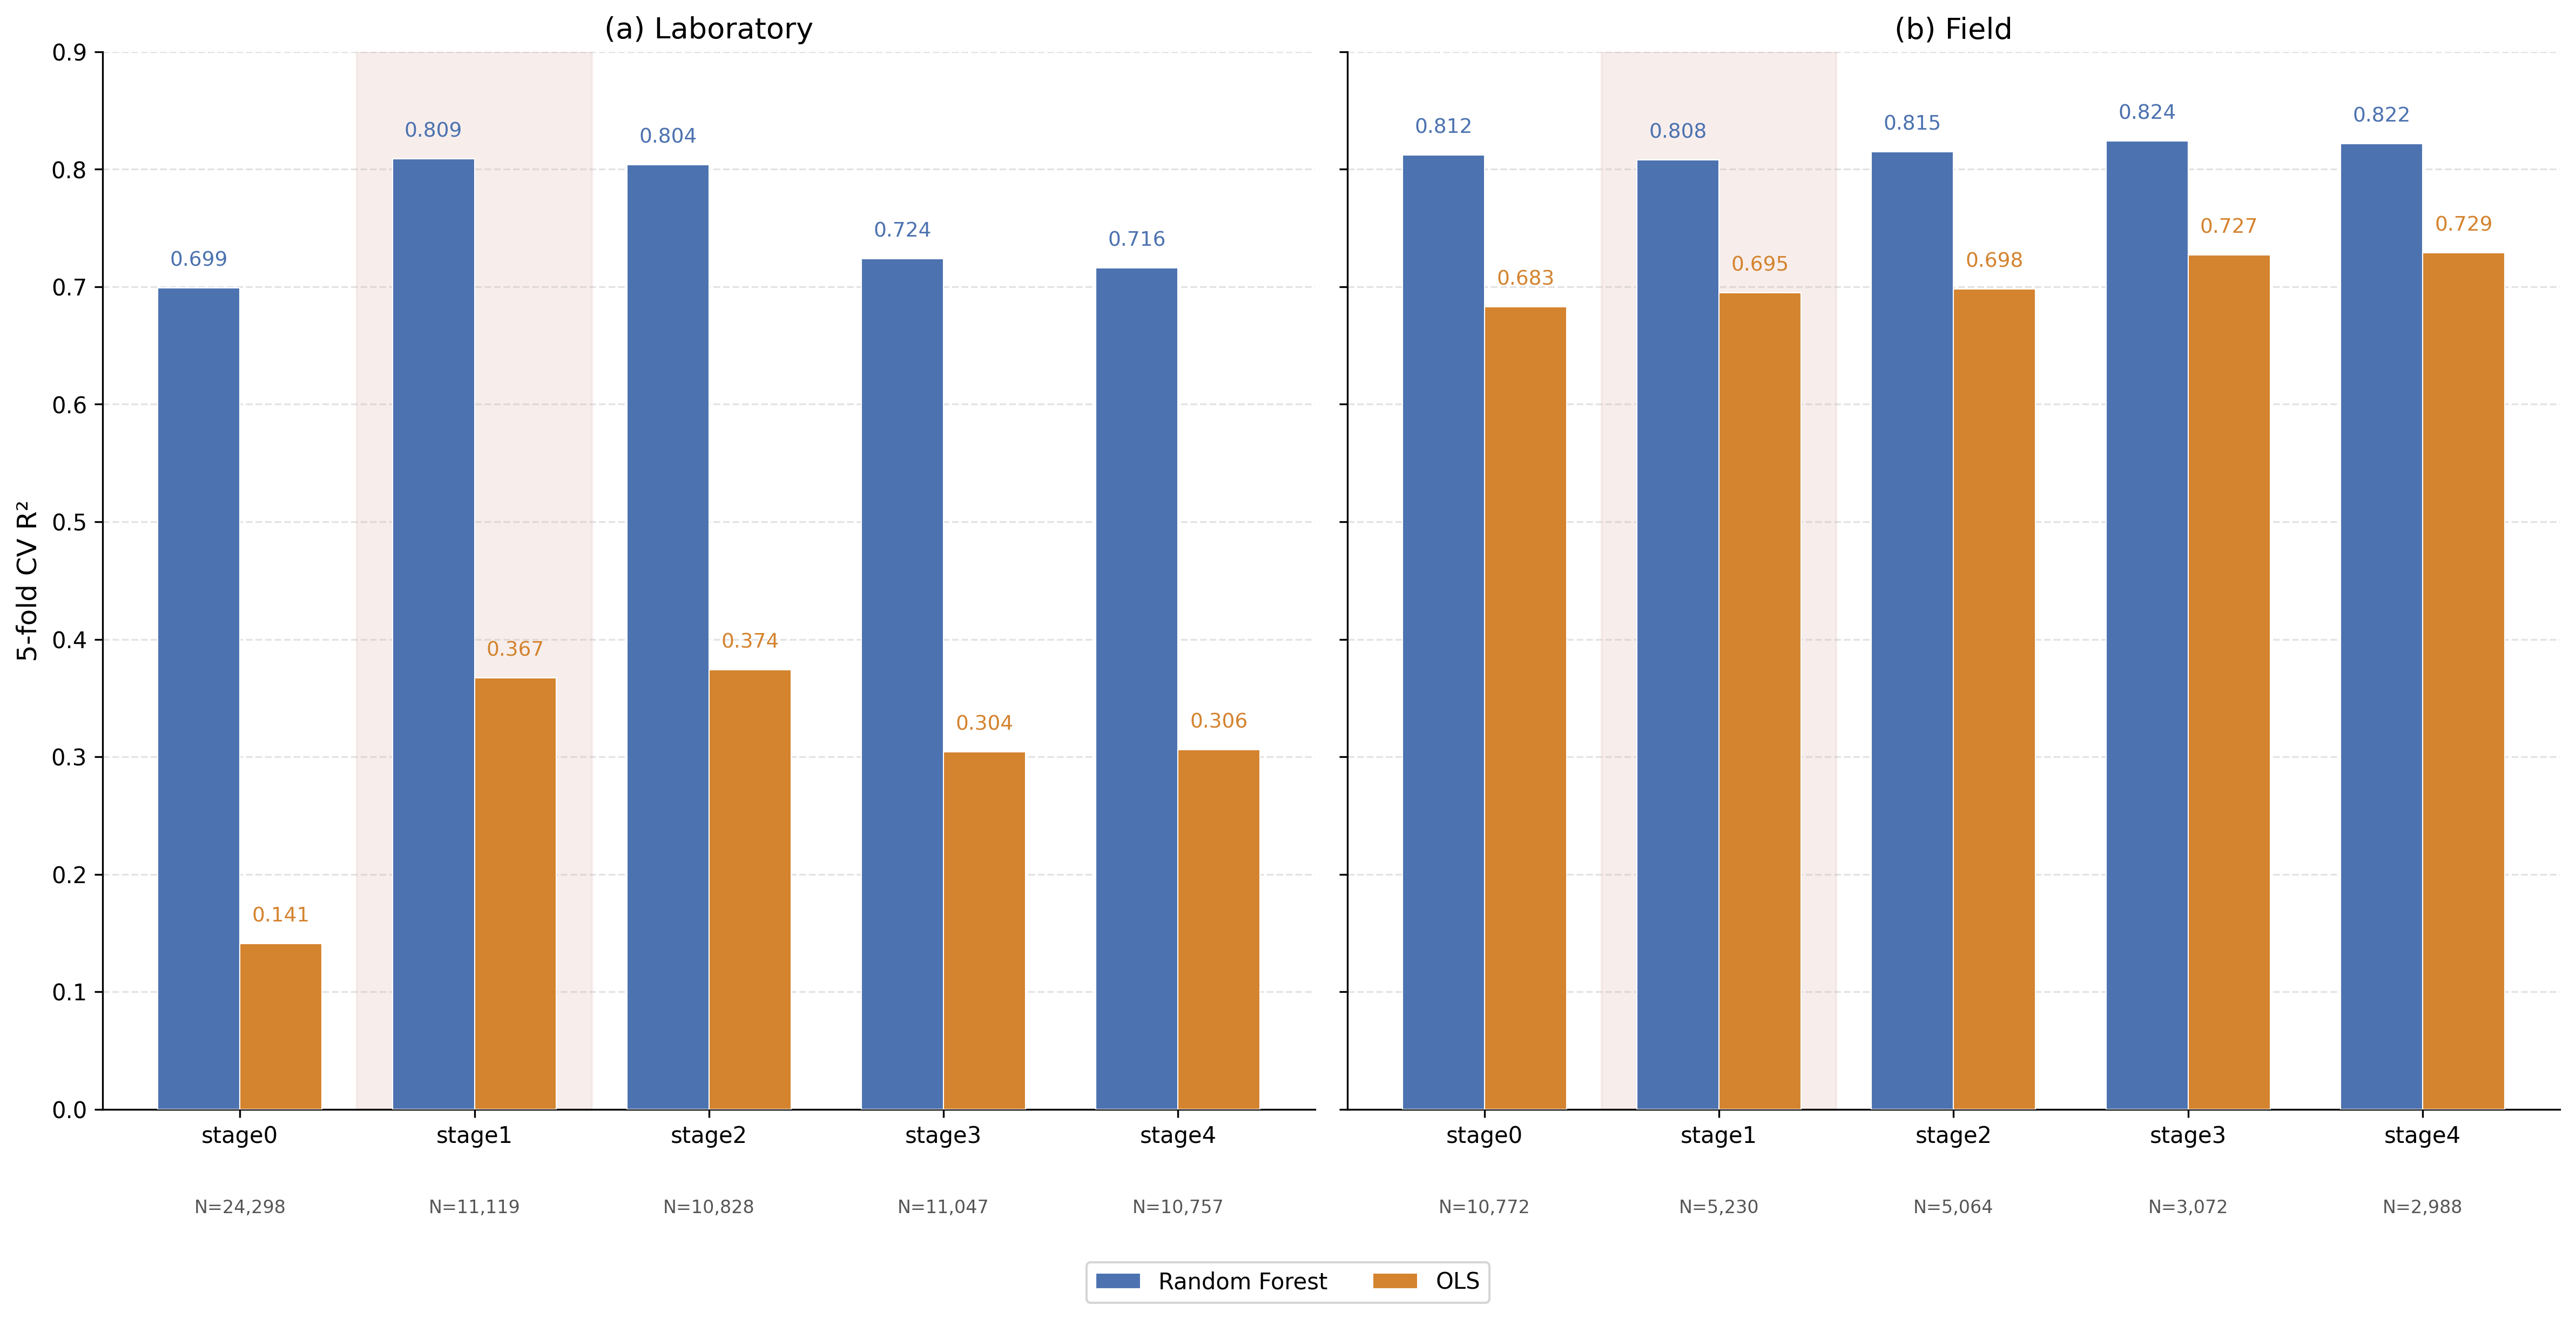

In [ ]:
# ============================================================
# Independent cell: Filtering sensitivity figure
# RF and OLS CV R² across BT_Vel target definitions
# Final manuscript style: stage0-stage4 only, stage1 shaded
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
OUTDIR = Path(".")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Filtering sensitivity data
# ------------------------------------------------------------
lab_filter = pd.DataFrame({
    "Dataset": "Lab",
    "Target": [
        "va_current (old formula)",
        "BT_Vel_stage0",
        "BT_Vel_stage1",
        "BT_Vel_stage2",
        "BT_Vel_stage3",
        "BT_Vel_stage4"
    ],
    "Short": ["old", "stage0", "stage1", "stage2", "stage3", "stage4"],
    "N": [24298, 24298, 11119, 10828, 11047, 10757],
    "OLS_CV_R2": [0.250, 0.141, 0.367, 0.374, 0.304, 0.306],
    "OLS_CV_R2_std": [0.019, 0.015, 0.014, 0.028, 0.011, 0.020],
    "RF_CV_R2": [0.774, 0.699, 0.809, 0.804, 0.724, 0.716],
    "RF_CV_R2_std": [0.031, 0.043, 0.031, 0.040, 0.033, 0.029],
})

field_filter = pd.DataFrame({
    "Dataset": "Field",
    "Target": [
        "va_current (old formula)",
        "BT_Vel_stage0",
        "BT_Vel_stage1",
        "BT_Vel_stage2",
        "BT_Vel_stage3",
        "BT_Vel_stage4"
    ],
    "Short": ["old", "stage0", "stage1", "stage2", "stage3", "stage4"],
    "N": [10772, 10772, 5230, 5064, 3072, 2988],
    "OLS_CV_R2": [0.494, 0.683, 0.695, 0.698, 0.727, 0.729],
    "OLS_CV_R2_std": [0.014, 0.009, 0.031, 0.016, 0.009, 0.024],
    "RF_CV_R2": [0.601, 0.812, 0.808, 0.815, 0.824, 0.822],
    "RF_CV_R2_std": [0.012, 0.007, 0.009, 0.011, 0.012, 0.018],
})

# ------------------------------------------------------------
# Save full table including old formula
# ------------------------------------------------------------
filter_df = pd.concat([lab_filter, field_filter], ignore_index=True)

csv_out = OUTDIR / "filtering_sensitivity_RF_OLS_final.csv"
xlsx_out = OUTDIR / "filtering_sensitivity_RF_OLS_final.xlsx"

filter_df.to_csv(csv_out, index=False)
filter_df.to_excel(xlsx_out, index=False)

print(f"Saved table: {csv_out}")
print(f"Saved table: {xlsx_out}")

try:
    display(filter_df)
except NameError:
    print(filter_df)

# ------------------------------------------------------------
# For manuscript figure: remove old/submitted and plot only stage0-stage4
# ------------------------------------------------------------
stage_order = ["stage0", "stage1", "stage2", "stage3", "stage4"]

lab_plot = lab_filter[lab_filter["Short"].isin(stage_order)].copy()
field_plot = field_filter[field_filter["Short"].isin(stage_order)].copy()

lab_plot["Short"] = pd.Categorical(lab_plot["Short"], categories=stage_order, ordered=True)
field_plot["Short"] = pd.Categorical(field_plot["Short"], categories=stage_order, ordered=True)

lab_plot = lab_plot.sort_values("Short").reset_index(drop=True)
field_plot = field_plot.sort_values("Short").reset_index(drop=True)

# ------------------------------------------------------------
# Figure style
# ------------------------------------------------------------
rf_color = "#4C72B0"
ols_color = "#D4832F"
shade_color = "#EEDAD7"

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True, dpi=300)

for ax, data, panel_label in [
    (axes[0], lab_plot, "(a) Laboratory"),
    (axes[1], field_plot, "(b) Field")
]:
    x = np.arange(len(data))
    w = 0.35

    # Shade main target stage1
    idx = list(data["Short"].astype(str)).index("stage1")
    ax.axvspan(
        idx - 0.5,
        idx + 0.5,
        color=shade_color,
        alpha=0.45,
        zorder=0
    )

    # Random Forest bars
    ax.bar(
        x - w / 2,
        data["RF_CV_R2"],
        w,
        label="Random Forest",
        color=rf_color,
        edgecolor="white",
        linewidth=0.5,
        zorder=3
    )

    # OLS bars
    ax.bar(
        x + w / 2,
        data["OLS_CV_R2"],
        w,
        label="OLS",
        color=ols_color,
        edgecolor="white",
        linewidth=0.5,
        zorder=3
    )

    # Value labels and N labels
    for i, row in data.iterrows():

        if pd.notna(row["RF_CV_R2"]):
            ax.text(
                x[i] - w / 2,
                row["RF_CV_R2"] + 0.015,
                f"{row['RF_CV_R2']:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="normal",
                color=rf_color
            )

        if pd.notna(row["OLS_CV_R2"]):
            ax.text(
                x[i] + w / 2,
                row["OLS_CV_R2"] + 0.015,
                f"{row['OLS_CV_R2']:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="normal",
                color=ols_color
            )

        ax.text(
            x[i],
            -0.085,
            f"N={int(row['N']):,}",
            ha="center",
            va="top",
            fontsize=8,
            transform=ax.get_xaxis_transform(),
            color="#555555"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        data["Short"].astype(str),
        fontsize=10,
        fontweight="normal",
        rotation=0
    )

    ax.set_title(
        panel_label,
        fontsize=13,
        fontweight="normal"
    )

    ax.set_ylim(0, 0.90)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("5-fold CV R²", fontsize=12, fontweight="normal")

# Shared legend below figure
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=True,
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

# ------------------------------------------------------------
# Save high-quality figure
# ------------------------------------------------------------
out_png = OUTDIR / "Filtering_Sensitivity_stage0_to_stage4_final.png"
out_pdf = OUTDIR / "Filtering_Sensitivity_stage0_to_stage4_final.pdf"

plt.savefig(out_png, bbox_inches="tight", facecolor="white", dpi=600)
plt.savefig(out_pdf, bbox_inches="tight", facecolor="white")

print(f"Saved figure: {out_png}")
print(f"Saved figure: {out_pdf}")

plt.show()

## 4. Bottom-track backscatter (`BS_rel`) Sensitivity

Saved table: bs_rel_ablation_stage1_final.csv
Saved table: bs_rel_ablation_stage1_final.xlsx


,Dataset,Model,Target,N_without_BS,N_with_BS,Without_BS_rel_CV_R2,With_BS_rel_CV_R2,Delta_R2
0,Lab,OLS,BT_Vel_stage1,11119,11118,0.3674,0.3963,0.0289
1,Lab,Random Forest,BT_Vel_stage1,11119,11118,0.8088,0.8173,0.0085
2,Lab,XGBoost,BT_Vel_stage1,11119,11118,0.7856,0.8027,0.0171
3,Lab,LightGBM,BT_Vel_stage1,11119,11118,0.7919,0.8012,0.0093
4,Lab,CatBoost,BT_Vel_stage1,11119,11118,0.7913,0.8116,0.0203
5,Field,OLS,BT_Vel_stage1,5230,5227,0.6955,0.6982,0.0027
6,Field,Random Forest,BT_Vel_stage1,5230,5227,0.8085,0.8127,0.0042
7,Field,XGBoost,BT_Vel_stage1,5230,5227,0.7807,0.7919,0.0112
8,Field,LightGBM,BT_Vel_stage1,5230,5227,0.7994,0.8017,0.0023
9,Field,CatBoost,BT_Vel_stage1,5230,5227,0.7937,0.7936,-0.0001


Saved figure: BS_rel_Ablation_stage1_final.png
Saved figure: BS_rel_Ablation_stage1_final.pdf


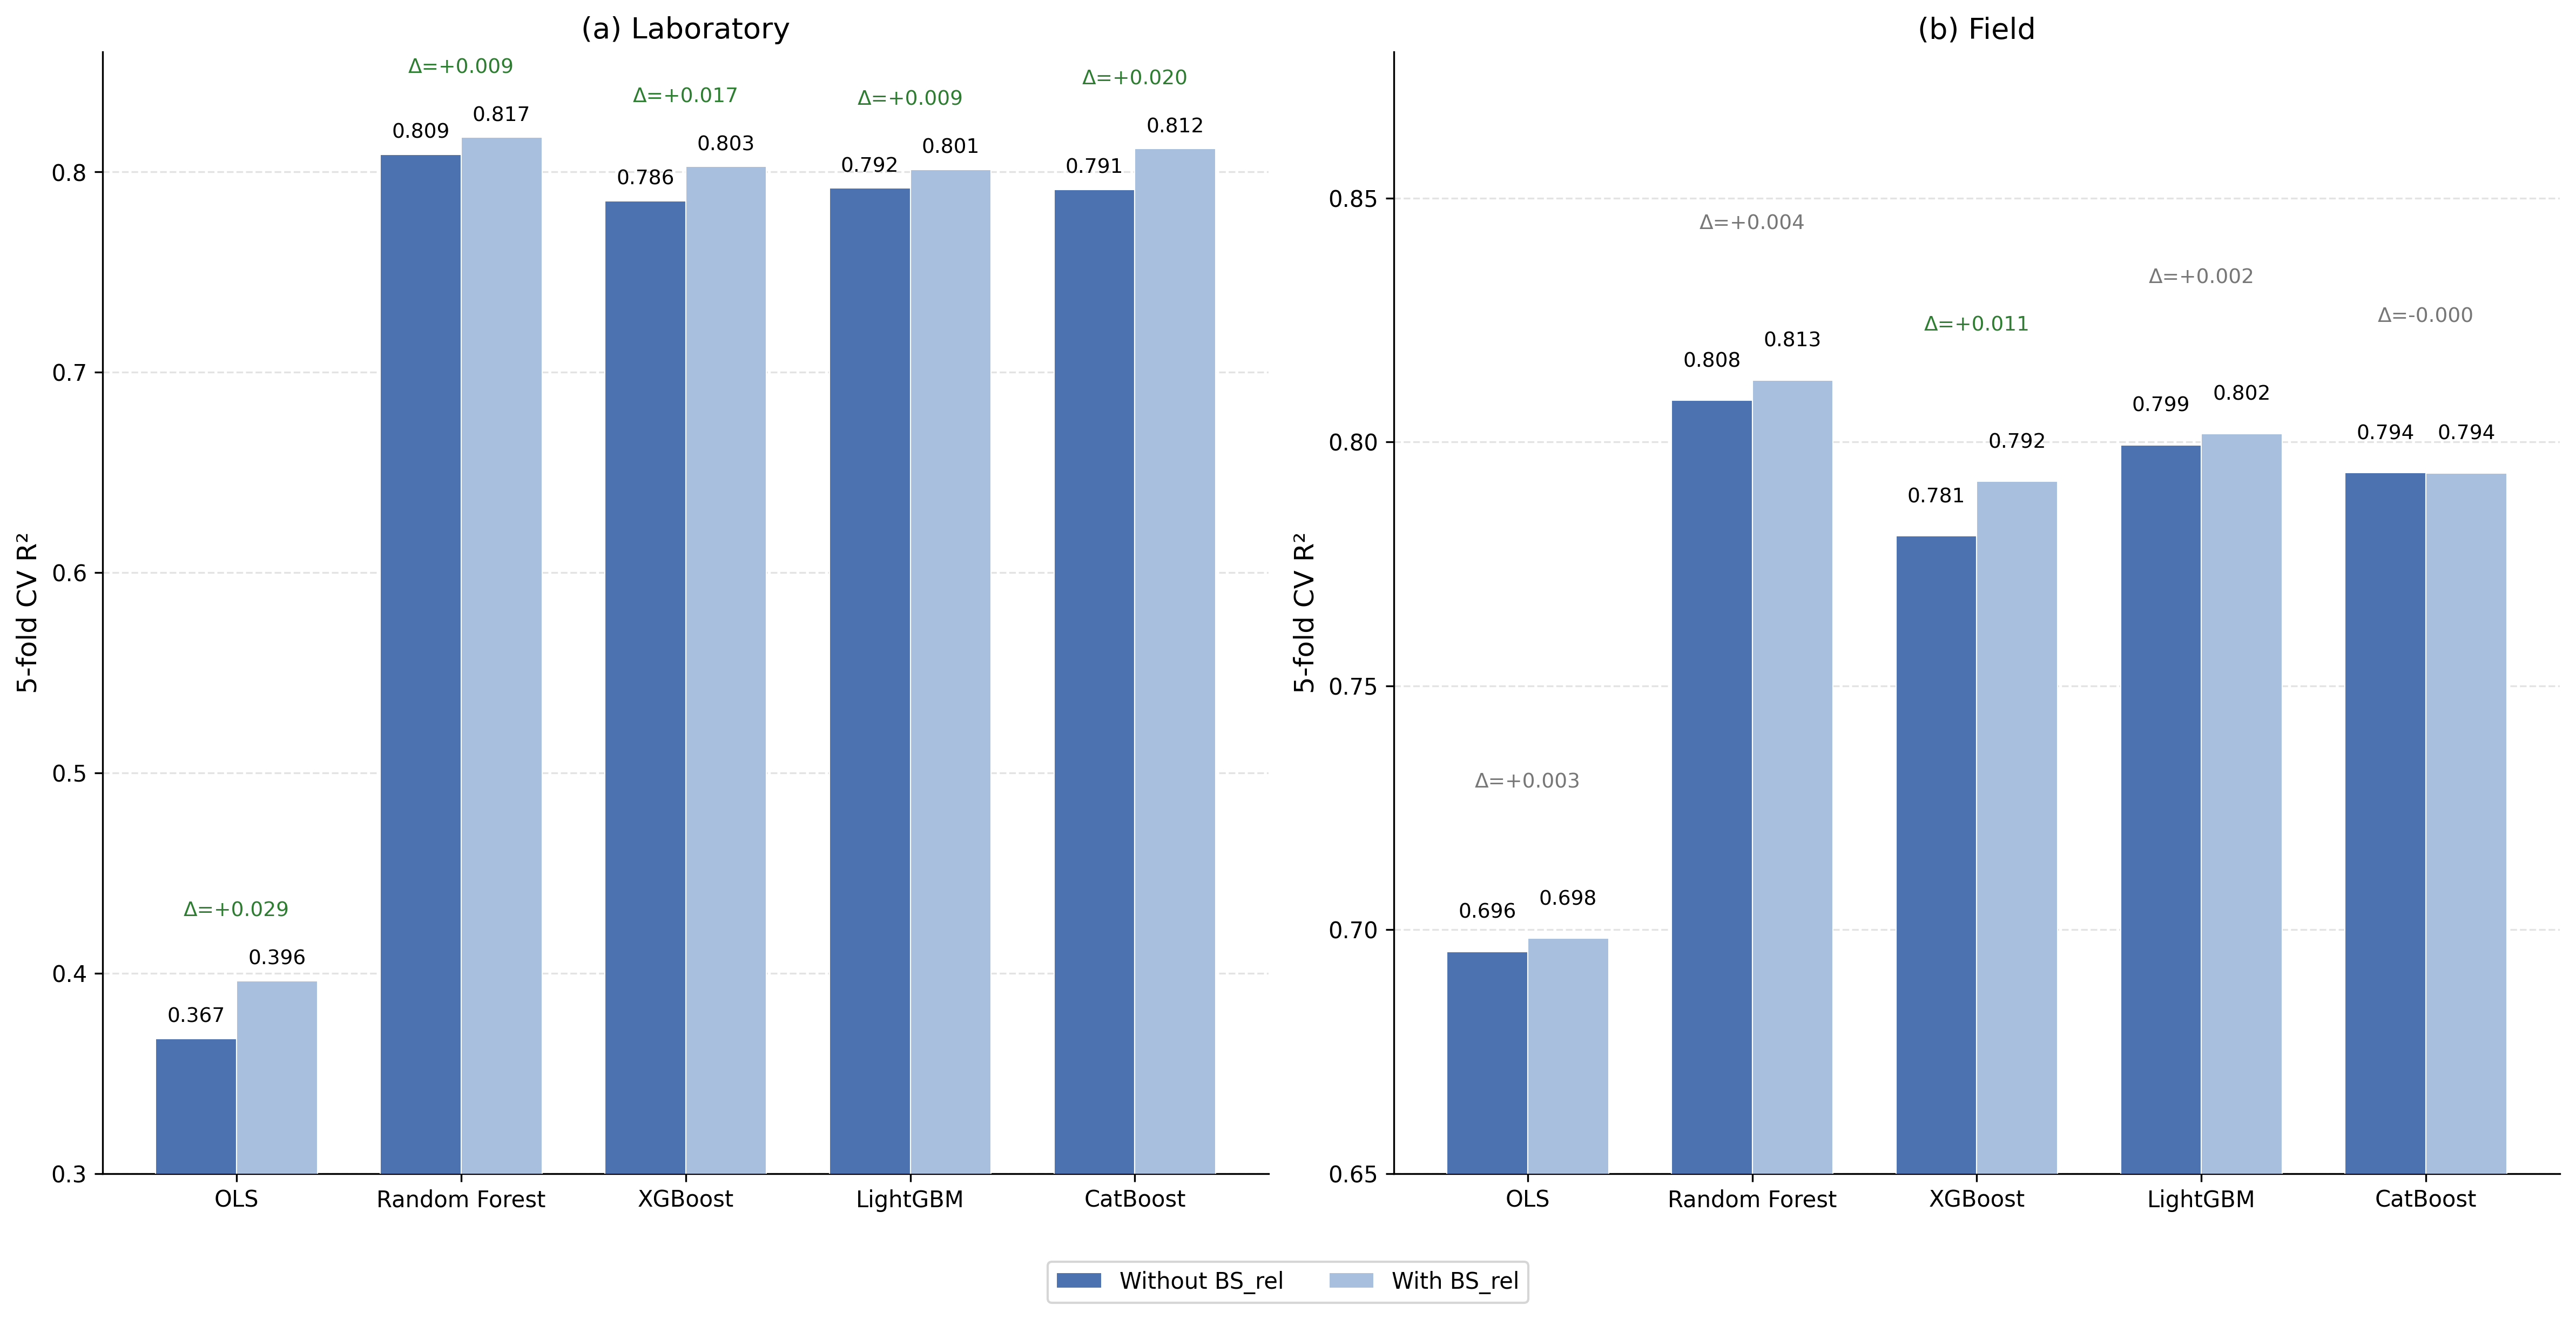

In [ ]:
# ============================================================
# Independent cell: BS_rel feature ablation figure
# Target = BT_Vel_stage1 for both laboratory and field datasets
# Final manuscript style
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
OUTDIR = Path(".")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# BS_rel ablation data
# ------------------------------------------------------------
bs_models = ["OLS", "Random Forest", "XGBoost", "LightGBM", "CatBoost"]

bs_lab = pd.DataFrame({
    "Dataset": "Lab",
    "Model": bs_models,
    "Target": "BT_Vel_stage1",
    "N_without_BS": 11119,
    "N_with_BS": 11118,
    "Without_BS_rel_CV_R2": [0.3674, 0.8088, 0.7856, 0.7919, 0.7913],
    "With_BS_rel_CV_R2":    [0.3963, 0.8173, 0.8027, 0.8012, 0.8116],
})

bs_field = pd.DataFrame({
    "Dataset": "Field",
    "Model": bs_models,
    "Target": "BT_Vel_stage1",
    "N_without_BS": 5230,
    "N_with_BS": 5227,
    "Without_BS_rel_CV_R2": [0.6955, 0.8085, 0.7807, 0.7994, 0.7937],
    "With_BS_rel_CV_R2":    [0.6982, 0.8127, 0.7919, 0.8017, 0.7936],
})

# ------------------------------------------------------------
# Combine, calculate delta, and save table
# ------------------------------------------------------------
bs_df = pd.concat([bs_lab, bs_field], ignore_index=True)

bs_df["Delta_R2"] = (
    bs_df["With_BS_rel_CV_R2"] - bs_df["Without_BS_rel_CV_R2"]
)

csv_out = OUTDIR / "bs_rel_ablation_stage1_final.csv"
xlsx_out = OUTDIR / "bs_rel_ablation_stage1_final.xlsx"

bs_df.to_csv(csv_out, index=False)
bs_df.to_excel(xlsx_out, index=False)

print(f"Saved table: {csv_out}")
print(f"Saved table: {xlsx_out}")

try:
    display(bs_df)
except NameError:
    print(bs_df)

# ------------------------------------------------------------
# Figure style
# ------------------------------------------------------------
without_color = "#4C72B0"
with_color = "#A8C0DE"

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False, dpi=300)

plot_specs = [
    (
        axes[0],
        bs_lab.assign(
            Delta_R2=bs_lab["With_BS_rel_CV_R2"] - bs_lab["Without_BS_rel_CV_R2"]
        ),
        "(a) Laboratory",
        0.30,
        0.86
    ),
    (
        axes[1],
        bs_field.assign(
            Delta_R2=bs_field["With_BS_rel_CV_R2"] - bs_field["Without_BS_rel_CV_R2"]
        ),
        "(b) Field",
        0.65,
        0.88
    ),
]

for ax, data, panel_label, ymin, ymax in plot_specs:

    x = np.arange(len(data))
    w = 0.36

    # Without BS_rel
    ax.bar(
        x - w / 2,
        data["Without_BS_rel_CV_R2"],
        w,
        label="Without BS_rel",
        color=without_color,
        edgecolor="white",
        linewidth=0.5,
        zorder=3
    )

    # With BS_rel
    ax.bar(
        x + w / 2,
        data["With_BS_rel_CV_R2"],
        w,
        label="With BS_rel",
        color=with_color,
        edgecolor="white",
        linewidth=0.5,
        zorder=3
    )

    # Value labels and delta labels
    for j, (_, row) in enumerate(data.iterrows()):

        ax.text(
            x[j] - w / 2,
            row["Without_BS_rel_CV_R2"] + 0.006,
            f"{row['Without_BS_rel_CV_R2']:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="normal",
            color="black"
        )

        ax.text(
            x[j] + w / 2,
            row["With_BS_rel_CV_R2"] + 0.006,
            f"{row['With_BS_rel_CV_R2']:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="normal",
            color="black"
        )

        sign = "+" if row["Delta_R2"] >= 0 else ""

        if row["Delta_R2"] > 0.005:
            delta_color = "#2E7D32"
        elif row["Delta_R2"] < -0.005:
            delta_color = "#A32D2D"
        else:
            delta_color = "#777777"

        ax.text(
            x[j],
            max(row["Without_BS_rel_CV_R2"], row["With_BS_rel_CV_R2"]) + 0.030,
            f"Δ={sign}{row['Delta_R2']:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="normal",
            color=delta_color
        )

    # X-axis
    ax.set_xticks(x)
    ax.set_xticklabels(
        data["Model"],
        rotation=0,
        fontsize=10,
        fontweight="normal"
    )

    # Panel label only, no large figure title
    ax.set_title(
        panel_label,
        fontsize=13,
        fontweight="normal"
    )

    ax.set_ylim(ymin, ymax)
    ax.set_ylabel("5-fold CV R²", fontsize=12, fontweight="normal")

    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Shared legend below figure
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=True,
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

# ------------------------------------------------------------
# Save high-quality figure
# ------------------------------------------------------------
out_png = OUTDIR / "BS_rel_Ablation_stage1_final.png"
out_pdf = OUTDIR / "BS_rel_Ablation_stage1_final.pdf"

plt.savefig(out_png, bbox_inches="tight", facecolor="white", dpi=600)
plt.savefig(out_pdf, bbox_inches="tight", facecolor="white")

print(f"Saved figure: {out_png}")
print(f"Saved figure: {out_pdf}")

plt.show()

## 5. Feature-set comparison



Saved table: feature_set_comparison_RF_final.csv
Saved table: feature_set_comparison_RF_final.xlsx


,Dataset,Feature_Set,N_features,CV_R2,CV_R2_std,N_rows
0,Lab,Physical only,6,0.7711,0.0178,11119
1,Lab,ADCP settings only,4,0.6733,0.0175,11119
2,Lab,Combined,10,0.8567,0.0201,11119
3,Field,Physical only,6,0.7804,0.0141,5230
4,Field,ADCP settings only,4,0.7354,0.0137,5247
5,Field,Combined,10,0.8125,0.0117,5230


Saved figure: Feature_Set_Comparison_RF_final.png
Saved figure: Feature_Set_Comparison_RF_final.pdf


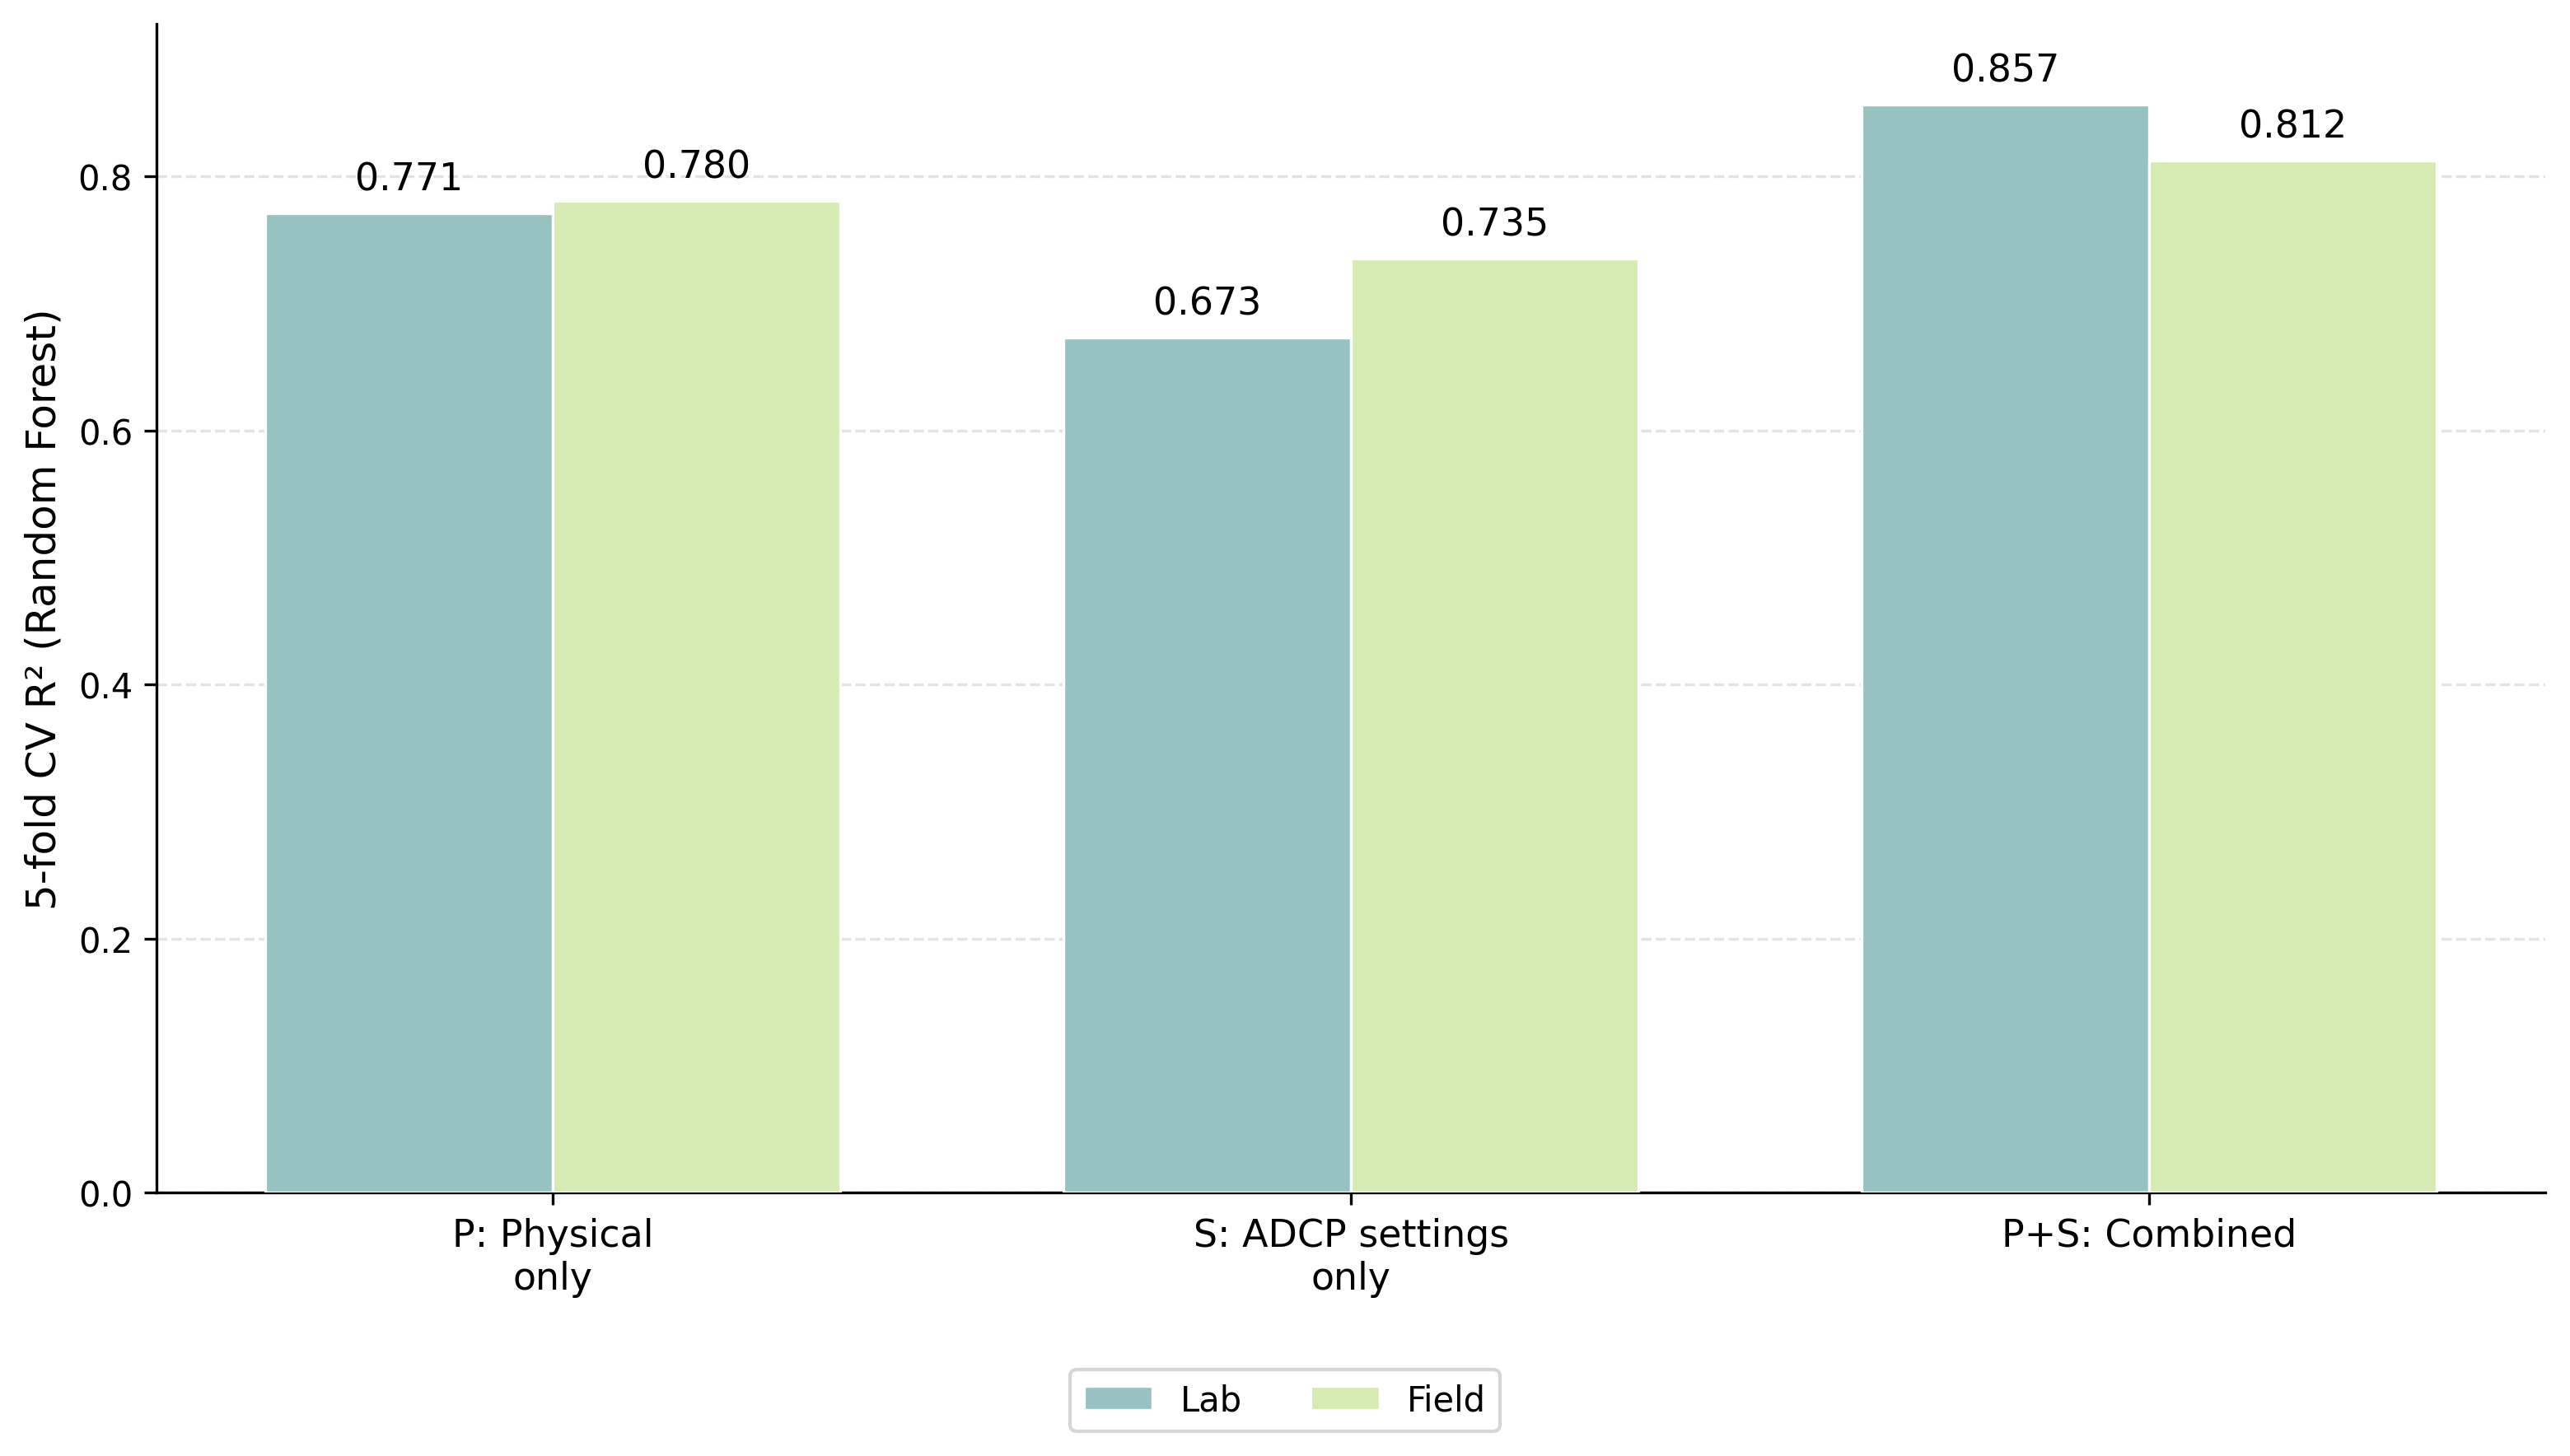

In [ ]:
# ============================================================
# Independent cell: Feature-set comparison figure
# Physical vs ADCP-settings vs Combined feature groups
# Random Forest, 5-fold CV R²
# Final manuscript style with bottom legend
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
OUTDIR = Path(".")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Feature-set comparison data
# ------------------------------------------------------------
feature_df = pd.DataFrame([
    ("Lab",   "Physical only",      6, 0.7711, 0.0178, 11119),
    ("Lab",   "ADCP settings only", 4, 0.6733, 0.0175, 11119),
    ("Lab",   "Combined",          10, 0.8567, 0.0201, 11119),

    ("Field", "Physical only",      6, 0.7804, 0.0141, 5230),
    ("Field", "ADCP settings only", 4, 0.7354, 0.0137, 5247),
    ("Field", "Combined",          10, 0.8125, 0.0117, 5230),
], columns=[
    "Dataset",
    "Feature_Set",
    "N_features",
    "CV_R2",
    "CV_R2_std",
    "N_rows"
])

# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------
csv_out = OUTDIR / "feature_set_comparison_RF_final.csv"
xlsx_out = OUTDIR / "feature_set_comparison_RF_final.xlsx"

feature_df.to_csv(csv_out, index=False)
feature_df.to_excel(xlsx_out, index=False)

print(f"Saved table: {csv_out}")
print(f"Saved table: {xlsx_out}")

try:
    display(feature_df)
except NameError:
    print(feature_df)

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
feature_order = [
    "Physical only",
    "ADCP settings only",
    "Combined"
]

feature_labels = [
    "P: Physical\nonly",
    "S: ADCP settings\nonly",
    "P+S: Combined"
]

lab_data = (
    feature_df[feature_df["Dataset"] == "Lab"]
    .set_index("Feature_Set")
    .loc[feature_order]
)

field_data = (
    feature_df[feature_df["Dataset"] == "Field"]
    .set_index("Feature_Set")
    .loc[feature_order]
)

lab_r2 = lab_data["CV_R2"].values
field_r2 = field_data["CV_R2"].values

# ------------------------------------------------------------
# Figure style
# ------------------------------------------------------------
x = np.arange(len(feature_order))
width = 0.36

lab_color = "#96C3C2"
field_color = "#D6EBB1"

fig, ax = plt.subplots(figsize=(10.5, 5.8), dpi=300)

bars_lab = ax.bar(
    x - width / 2,
    lab_r2,
    width,
    label="Lab",
    color=lab_color,
    edgecolor="white",
    linewidth=0.8,
    zorder=3
)

bars_field = ax.bar(
    x + width / 2,
    field_r2,
    width,
    label="Field",
    color=field_color,
    edgecolor="white",
    linewidth=0.8,
    zorder=3
)

# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------
for bars in [bars_lab, bars_field]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.012,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="normal",
            color="black"
        )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(
    feature_labels,
    fontsize=11,
    fontweight="normal"
)

ax.set_ylabel(
    "5-fold CV R² (Random Forest)",
    fontsize=12,
    fontweight="normal"
)

ax.set_ylim(0.0, 0.92)

# No internal title for manuscript
ax.set_title("")

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Shared bottom legend, same style as previous plots
# ------------------------------------------------------------
handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=True,
    fontsize=10
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# ------------------------------------------------------------
# Save high-quality figure
# ------------------------------------------------------------
out_png = OUTDIR / "Feature_Set_Comparison_RF_final.png"
out_pdf = OUTDIR / "Feature_Set_Comparison_RF_final.pdf"

plt.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(out_pdf, bbox_inches="tight", facecolor="white")

print(f"Saved figure: {out_png}")
print(f"Saved figure: {out_pdf}")

plt.show()